
<div dir=ltr align=center>

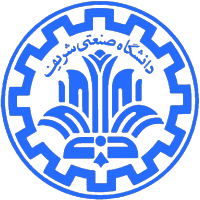

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Virtual Autoencoder<br>
<font color=696880 size=4>
Prepared by Group 38

____

In [2]:
# Group Members
Names = [
    'Farid Mahmoudzadeh',
    'Parsa Malekian',
    'Fatemeh Shafiee',
]
Studen_IDs = [
    '401106493',
    '402171075',
    '402110877',
]



# Setup

## Imports

In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Reproducibility

In [4]:
# Set global seed for reproducibility
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Provide Data + EDA

## Data Provision

In [5]:
# ==============================
# Download / Load Dataset
# ==============================

data_dir = "./data"

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))   # Normalize to [-1, 1]
])

# Load full training set
full_train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)
# Train / Validation Split
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Load test set
test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [6]:
# Dataset Samples
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# Image Shape
sample_image, sample_label = train_dataset[0]
print("Single image shape:", sample_image.shape)

Train samples: 54000
Validation samples: 6000
Test samples: 10000
Single image shape: torch.Size([1, 28, 28])


In [7]:
# ==============================
# DataLoaders
# ==============================

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 422
Validation batches: 47
Test batches: 79


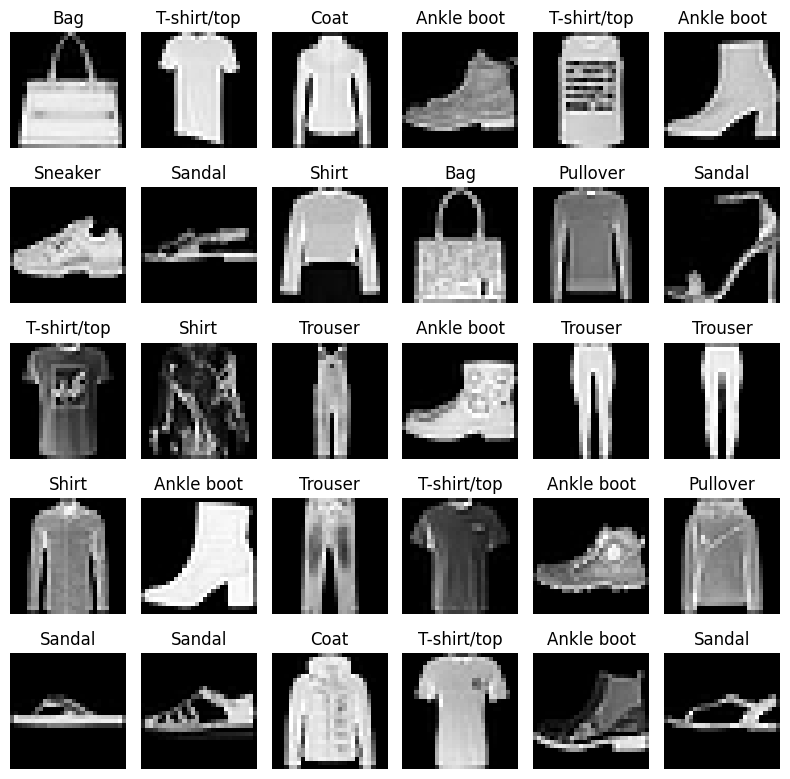

In [8]:
# ==============================
# Sanity Check (30 pictures)
# ==============================

class_names = full_train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(5, 6, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.5 + 0.5  # Unnormalize for display
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## EDA

T-shirt/top: 5342
Trouser: 5389
Pullover: 5388
Dress: 5438
Coat: 5393
Sandal: 5387
Shirt: 5400
Sneaker: 5463
Bag: 5402
Ankle boot: 5398


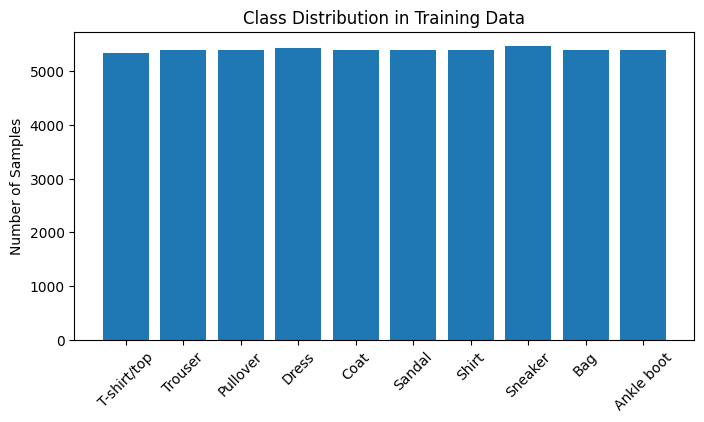

In [9]:
# ==============================
# Class Distribution
# ==============================

all_labels = []

for _, labels in train_dataset:
    all_labels.append(labels)

all_labels = np.array(all_labels)

unique, counts = np.unique(all_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{class_names[u]}: {c}")

plt.figure(figsize=(8,4))
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Samples")
plt.show()

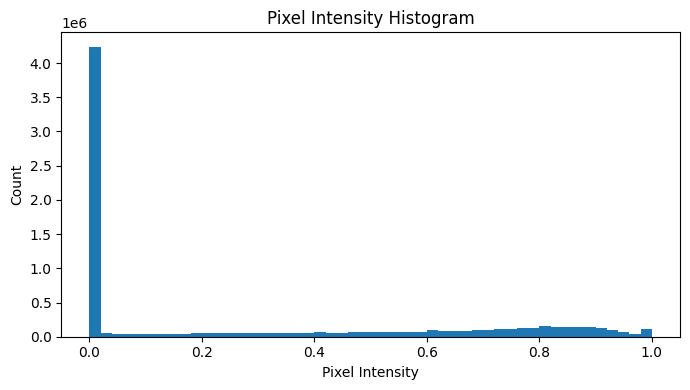

In [10]:
# ==============================
# Pixel Intensity Histogram
# ==============================

def sample_pixels(loader, max_batches=80):
    pixels = []
    used = 0
    for img, _ in loader:
        # flatten and unnormalize for intensity display
        pixels.append((img.view(-1)*0.5+0.5).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(pixels, axis=0)

pixels = sample_pixels(train_loader)
plt.figure(figsize=(7,4))
plt.hist(pixels, bins=50)
plt.title('Pixel Intensity Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

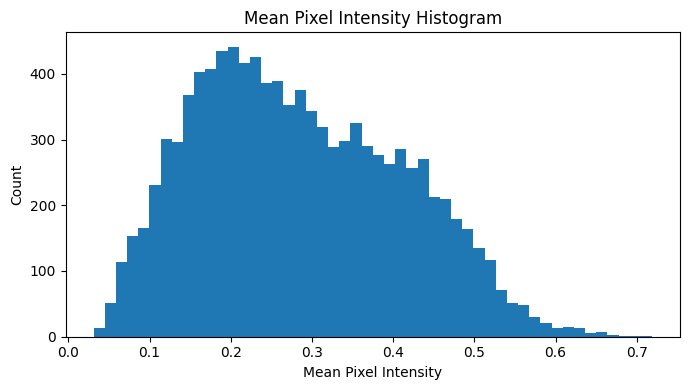

In [11]:
# ==============================
# Mean Pixel Intensity per Image
# ==============================

def sample_means(loader, max_batches=80):
    means = []
    used = 0
    for img, _ in loader:
        # Unnormalize for intensity display
        means.append((img.view(img.size(0), -1)*0.5+0.5).mean(dim=1).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(means, axis=0)

means = sample_means(train_loader)
plt.figure(figsize=(7,4))
plt.hist(means, bins=50)
plt.title('Mean Pixel Intensity Histogram')
plt.xlabel('Mean Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Phase 2 — VAE Implementation and Output Quality

### (A) Hyperparameters

In [12]:
LATENT_DIM = 16
LR = 1e-3
EPOCHS = 20
BETA = 1.0           # base model: KL weight = 1 (as requested)

### (B) VAE Model (from scratch)


Our inputs are normalized to [-1, 1], so the decoder output uses Tanh and reconstruction loss uses MSE.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: (B,1,28,28) -> (B,128,7,7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7 -> 7
            nn.ReLU(True),
        )
        self.enc_flat_dim = 128 * 7 * 7

        # Latent parameters
        self.fc_mu = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, latent_dim)

        # Decoder: z -> (B,1,28,28)
        self.fc_dec = nn.Linear(latent_dim, self.enc_flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # output in [-1, 1]
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, 7, 7)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

### (C) Loss Function (Reconstruction + Regularization)
We choose MSE as reconstruction loss (fixed).

KL regularization is computed for $q(z|x)=\mathcal{N}(\mu,\sigma^2)$ vs $p(z)=\mathcal{N}(0, I)$.

In [14]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE), averaged per batch
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    # KL divergence, averaged per batch
    kl = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)

    total = recon + beta * kl
    return total, recon, kl

### (D) Train / Validation / Test Loops

This will let you report test reconstruction, test regularization (KL), and test total exactly as requested.

In [15]:
def run_epoch(model, loader, optimizer=None, beta=1.0, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
    n_batches = 0

    for x, _ in loader:
        x = x.to(device)

        if is_train:
            optimizer.zero_grad()

        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "recon": total_recon / n_batches,
        "kl": total_kl / n_batches,
    }

### (E) Training the Base VAE (beta=1)

In [16]:
model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(model, train_loader, optimizer=optimizer, beta=BETA, device=device)
    val_m   = run_epoch(model, val_loader, optimizer=None, beta=BETA, device=device)

    history["train"].append(train_m)
    history["val"].append(val_m)

    print(
        f"Epoch {epoch:02d} | "
        f"train: loss={train_m['loss']:.4f}, recon={train_m['recon']:.4f}, kl={train_m['kl']:.4f} | "
        f"val: loss={val_m['loss']:.4f}, recon={val_m['recon']:.4f}, kl={val_m['kl']:.4f}"
    )

Epoch 01 | train: loss=112.4599, recon=95.1413, kl=17.3185 | val: loss=73.6182, recon=54.5972, kl=19.0209
Epoch 02 | train: loss=69.4716, recon=50.3749, kl=19.0967 | val: loss=67.3920, recon=47.7582, kl=19.6338
Epoch 03 | train: loss=65.3282, recon=45.8798, kl=19.4484 | val: loss=64.5332, recon=44.5917, kl=19.9414
Epoch 04 | train: loss=63.4493, recon=43.8663, kl=19.5829 | val: loss=63.4556, recon=44.7197, kl=18.7359
Epoch 05 | train: loss=62.1096, recon=42.5071, kl=19.6025 | val: loss=62.3729, recon=42.8478, kl=19.5251
Epoch 06 | train: loss=61.1485, recon=41.4746, kl=19.6739 | val: loss=61.5843, recon=42.6752, kl=18.9091
Epoch 07 | train: loss=60.4448, recon=40.7667, kl=19.6781 | val: loss=60.8347, recon=40.6729, kl=20.1618
Epoch 08 | train: loss=59.8816, recon=40.1838, kl=19.6978 | val: loss=60.4538, recon=40.7481, kl=19.7057
Epoch 09 | train: loss=59.4151, recon=39.6921, kl=19.7230 | val: loss=60.3166, recon=41.4549, kl=18.8616
Epoch 10 | train: loss=59.0198, recon=39.2975, kl=19.7

Loss curves:

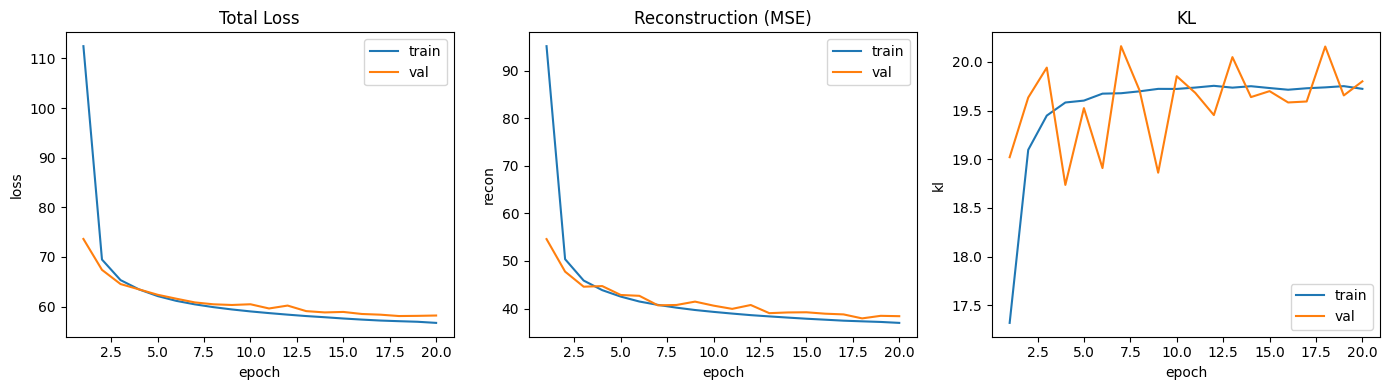

In [17]:
def plot_history(history):
    epochs = np.arange(1, len(history["train"]) + 1)

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, [h["loss"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["loss"] for h in history["val"]], label="val")
    plt.title("Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, [h["recon"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["recon"] for h in history["val"]], label="val")
    plt.title("Reconstruction (MSE)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, [h["kl"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["kl"] for h in history["val"]], label="val")
    plt.title("KL")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### (F) Test Set Report (Reconstruction / Regularization / Total)

This is exactly what the project asks you to report on the test set.

In [18]:
test_m = run_epoch(model, test_loader, optimizer=None, beta=BETA, device=device)

print("\nTEST SET METRICS (base VAE, beta=1):")
print(f"reconstruction (MSE): {test_m['recon']:.6f}")
print(f"regularization (KL):  {test_m['kl']:.6f}")
print(f"total:               {test_m['loss']:.6f}")


TEST SET METRICS (base VAE, beta=1):
reconstruction (MSE): 38.553712
regularization (KL):  19.690304
total:               58.244016


### (G) Reconstruction Visualization (≥ 20 input/output pairs)

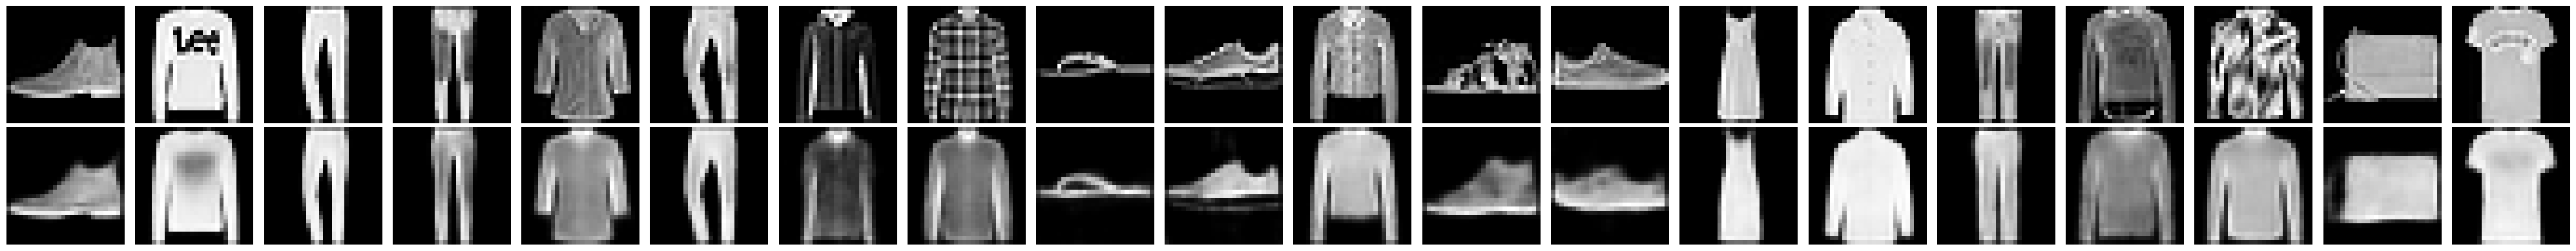

In [19]:
def show_reconstructions(model, loader, n=20, device="cuda"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    with torch.no_grad():
        x_hat, _, _ = model(x)

    # Unnormalize for display: [-1,1] -> [0,1]
    x_vis = (x.cpu() * 0.5) + 0.5
    xhat_vis = (x_hat.cpu() * 0.5) + 0.5

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(x_vis[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(xhat_vis[i, 0], cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Input", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=20, device=device)

### (H) Sampling Visualization (≥ 50 generated images)

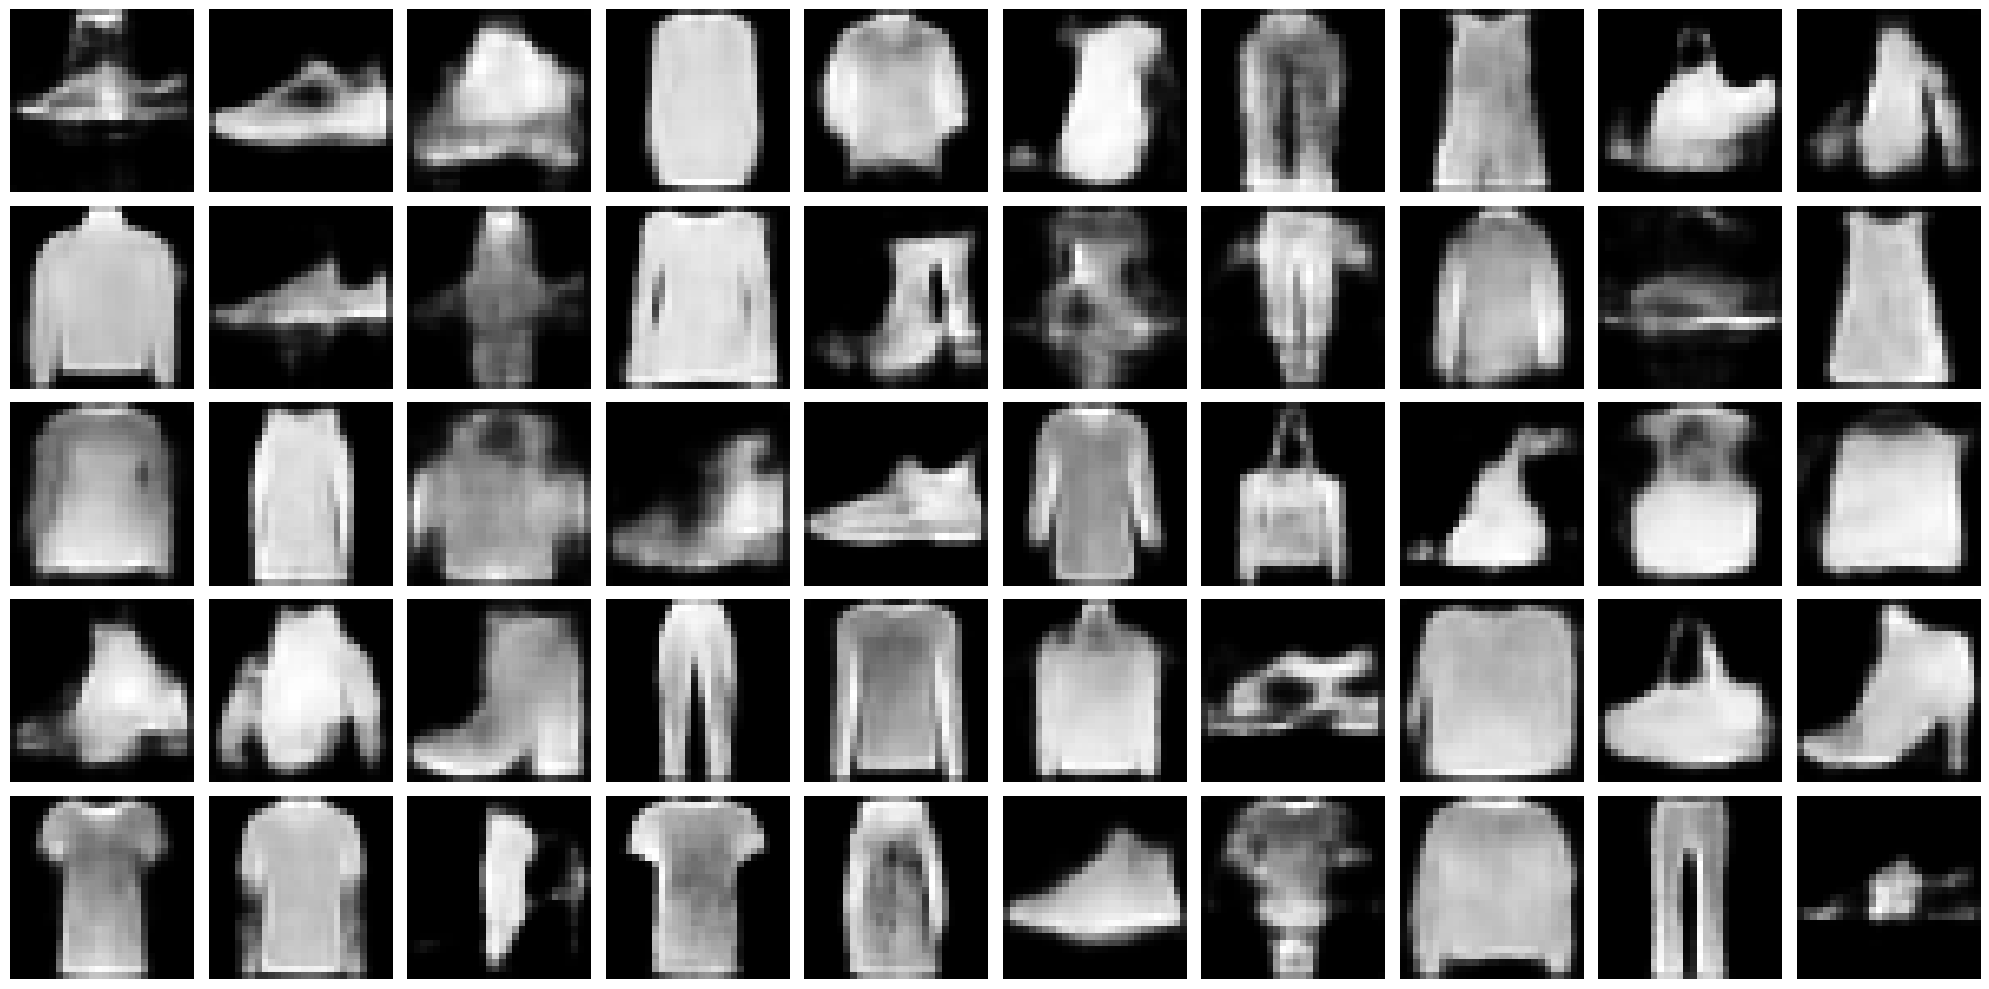

In [20]:
def sample_from_prior(model, n=50, device="cuda"):
    model.eval()
    z = torch.randn(n, model.latent_dim).to(device)

    with torch.no_grad():
        x_gen = model.decode(z)

    x_vis = (x_gen.cpu() * 0.5) + 0.5

    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(x_vis[i, 0], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

sample_from_prior(model, n=50, device=device)

## Phase 2 - improvement

### 0) Keep baseline model safely

In [22]:
import copy

baseline_model = copy.deepcopy(model).to(device)
baseline_latent_dim = baseline_model.latent_dim
baseline_beta = BETA  # should be 1.0

# Evaluate baseline on test (again, to store values for the comparison table)
baseline_test = run_epoch(baseline_model, test_loader, optimizer=None, beta=baseline_beta, device=device)

print("\nBASELINE TEST METRICS:")
print(f"reconstruction (MSE): {baseline_test['recon']:.6f}")
print(f"regularization (KL):  {baseline_test['kl']:.6f}")
print(f"total:               {baseline_test['loss']:.6f}")


BASELINE TEST METRICS:
reconstruction (MSE): 38.673536
regularization (KL):  19.690304
total:               58.363840


 -----------------------------
### 1) Improved model setup
Change: latent dimension
 -----------------------------

In [24]:
IMPROVED_LATENT_DIM = 64
IMPROVED_EPOCHS = EPOCHS     # keep same epochs for fair comparison
IMPROVED_LR = LR
IMPROVED_BETA = 1.0          # keep beta=1 like baseline (only change latent dim)

improved_model = ConvVAE(latent_dim=IMPROVED_LATENT_DIM).to(device)
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=IMPROVED_LR)

improved_history = {"train": [], "val": []}

print(f"\nTraining IMPROVED model: latent_dim={IMPROVED_LATENT_DIM}, beta={IMPROVED_BETA}")
for epoch in range(1, IMPROVED_EPOCHS + 1):
    train_m = run_epoch(improved_model, train_loader, optimizer=improved_optimizer,
                        beta=IMPROVED_BETA, device=device)
    val_m   = run_epoch(improved_model, val_loader, optimizer=None,
                        beta=IMPROVED_BETA, device=device)

    improved_history["train"].append(train_m)
    improved_history["val"].append(val_m)

    print(
        f"Epoch {epoch:02d} | "
        f"train: loss={train_m['loss']:.4f}, recon={train_m['recon']:.4f}, kl={train_m['kl']:.4f} | "
        f"val: loss={val_m['loss']:.4f}, recon={val_m['recon']:.4f}, kl={val_m['kl']:.4f}"
    )


Training IMPROVED model: latent_dim=64, beta=1.0
Epoch 01 | train: loss=123.5478, recon=102.7920, kl=20.7557 | val: loss=79.5478, recon=58.6163, kl=20.9314
Epoch 02 | train: loss=73.5891, recon=52.5084, kl=21.0807 | val: loss=70.6034, recon=49.7776, kl=20.8258
Epoch 03 | train: loss=68.3318, recon=47.2574, kl=21.0744 | val: loss=67.4038, recon=47.0039, kl=20.3999
Epoch 04 | train: loss=65.8854, recon=44.8549, kl=21.0305 | val: loss=65.3582, recon=44.0947, kl=21.2635
Epoch 05 | train: loss=64.2931, recon=43.2527, kl=21.0404 | val: loss=64.4059, recon=43.7744, kl=20.6315
Epoch 06 | train: loss=63.1920, recon=42.2345, kl=20.9575 | val: loss=63.2057, recon=41.7842, kl=21.4215
Epoch 07 | train: loss=62.2342, recon=41.3348, kl=20.8993 | val: loss=62.8089, recon=42.5577, kl=20.2512
Epoch 08 | train: loss=61.6021, recon=40.7424, kl=20.8597 | val: loss=62.4265, recon=41.3566, kl=21.0699
Epoch 09 | train: loss=61.0709, recon=40.2484, kl=20.8225 | val: loss=61.5972, recon=40.1183, kl=21.4789
Epo


 -----------------------------
### 2) Evaluate improved on test
 -----------------------------

In [25]:
improved_test = run_epoch(improved_model, test_loader, optimizer=None, beta=IMPROVED_BETA, device=device)

print("\nIMPROVED TEST METRICS:")
print(f"reconstruction (MSE): {improved_test['recon']:.6f}")
print(f"regularization (KL):  {improved_test['kl']:.6f}")
print(f"total:               {improved_test['loss']:.6f}")


IMPROVED TEST METRICS:
reconstruction (MSE): 38.453074
regularization (KL):  20.509882
total:               58.962956


 -----------------------------
### 3) Comparison table (test set)
 ---

In [26]:
print("\nTEST SET COMPARISON TABLE")
print("-" * 90)
print(f"{'Model':<12} {'latent_dim':<10} {'beta':<6} {'recon(MSE)':<14} {'KL':<14} {'total':<14}")
print("-" * 90)
print(f"{'Baseline':<12} {baseline_latent_dim:<10d} {baseline_beta:<6.2f} "
      f"{baseline_test['recon']:<14.6f} {baseline_test['kl']:<14.6f} {baseline_test['loss']:<14.6f}")
print(f"{'Improved':<12} {IMPROVED_LATENT_DIM:<10d} {IMPROVED_BETA:<6.2f} "
      f"{improved_test['recon']:<14.6f} {improved_test['kl']:<14.6f} {improved_test['loss']:<14.6f}")
print("-" * 90)


TEST SET COMPARISON TABLE
------------------------------------------------------------------------------------------
Model        latent_dim beta   recon(MSE)     KL             total         
------------------------------------------------------------------------------------------
Baseline     16         1.00   38.673536      19.690304      58.363840     
Improved     64         1.00   38.453074      20.509882      58.962956     
------------------------------------------------------------------------------------------


 -----------------------------
### 4) Visual comparison: reconstructions (>= 20)
 -----------------------------


Reconstructions BEFORE (Baseline):


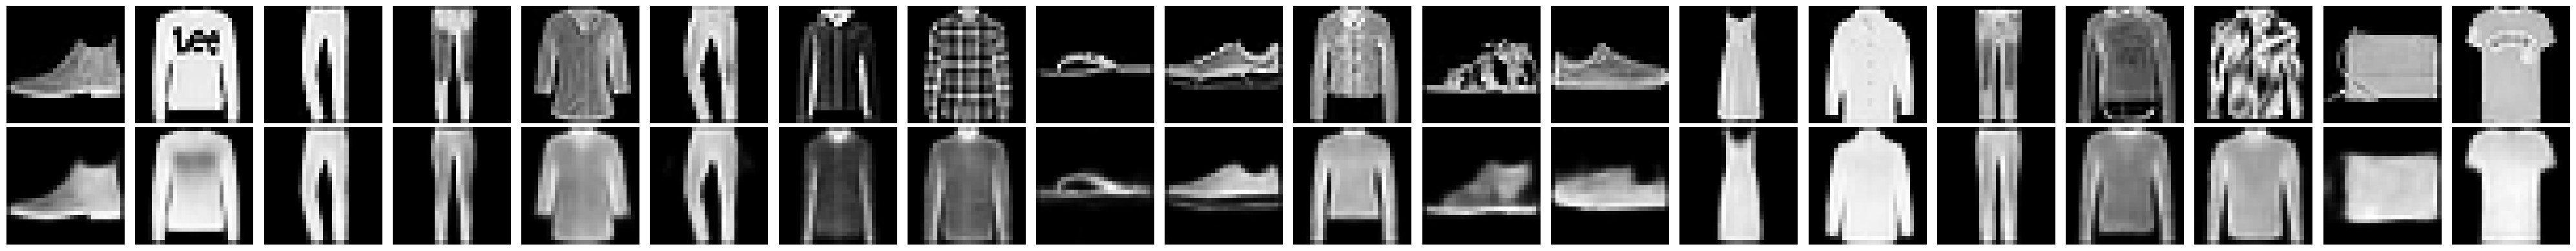


Reconstructions AFTER (Improved):


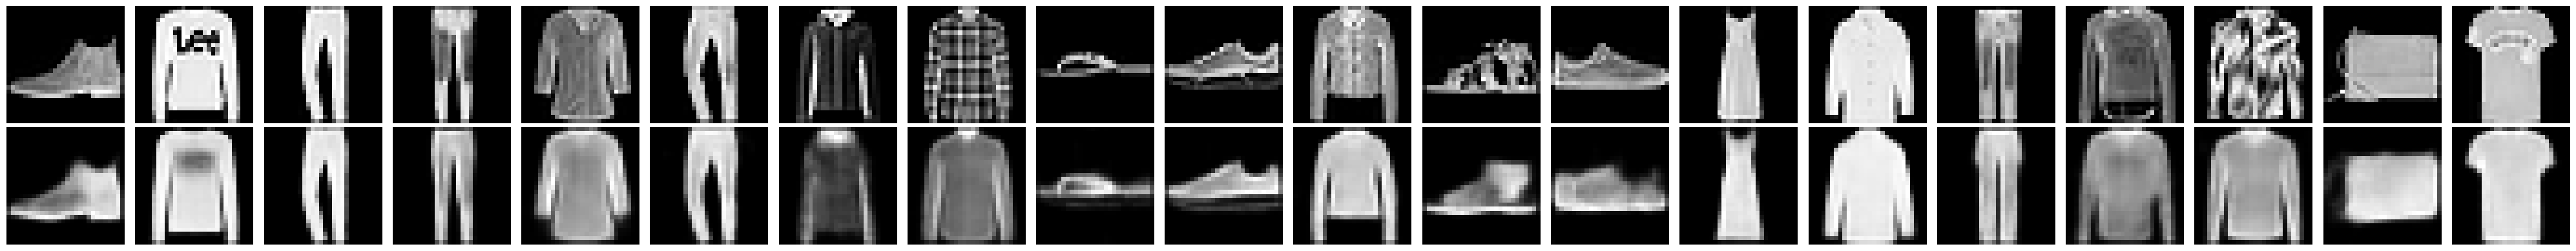

In [27]:
print("\nReconstructions BEFORE (Baseline):")
show_reconstructions(baseline_model, test_loader, n=20, device=device)

print("\nReconstructions AFTER (Improved):")
show_reconstructions(improved_model, test_loader, n=20, device=device)

 -----------------------------
### 5) Visual comparison: sampling (>= 50)
 -----------------------------


Sampling BEFORE (Baseline):


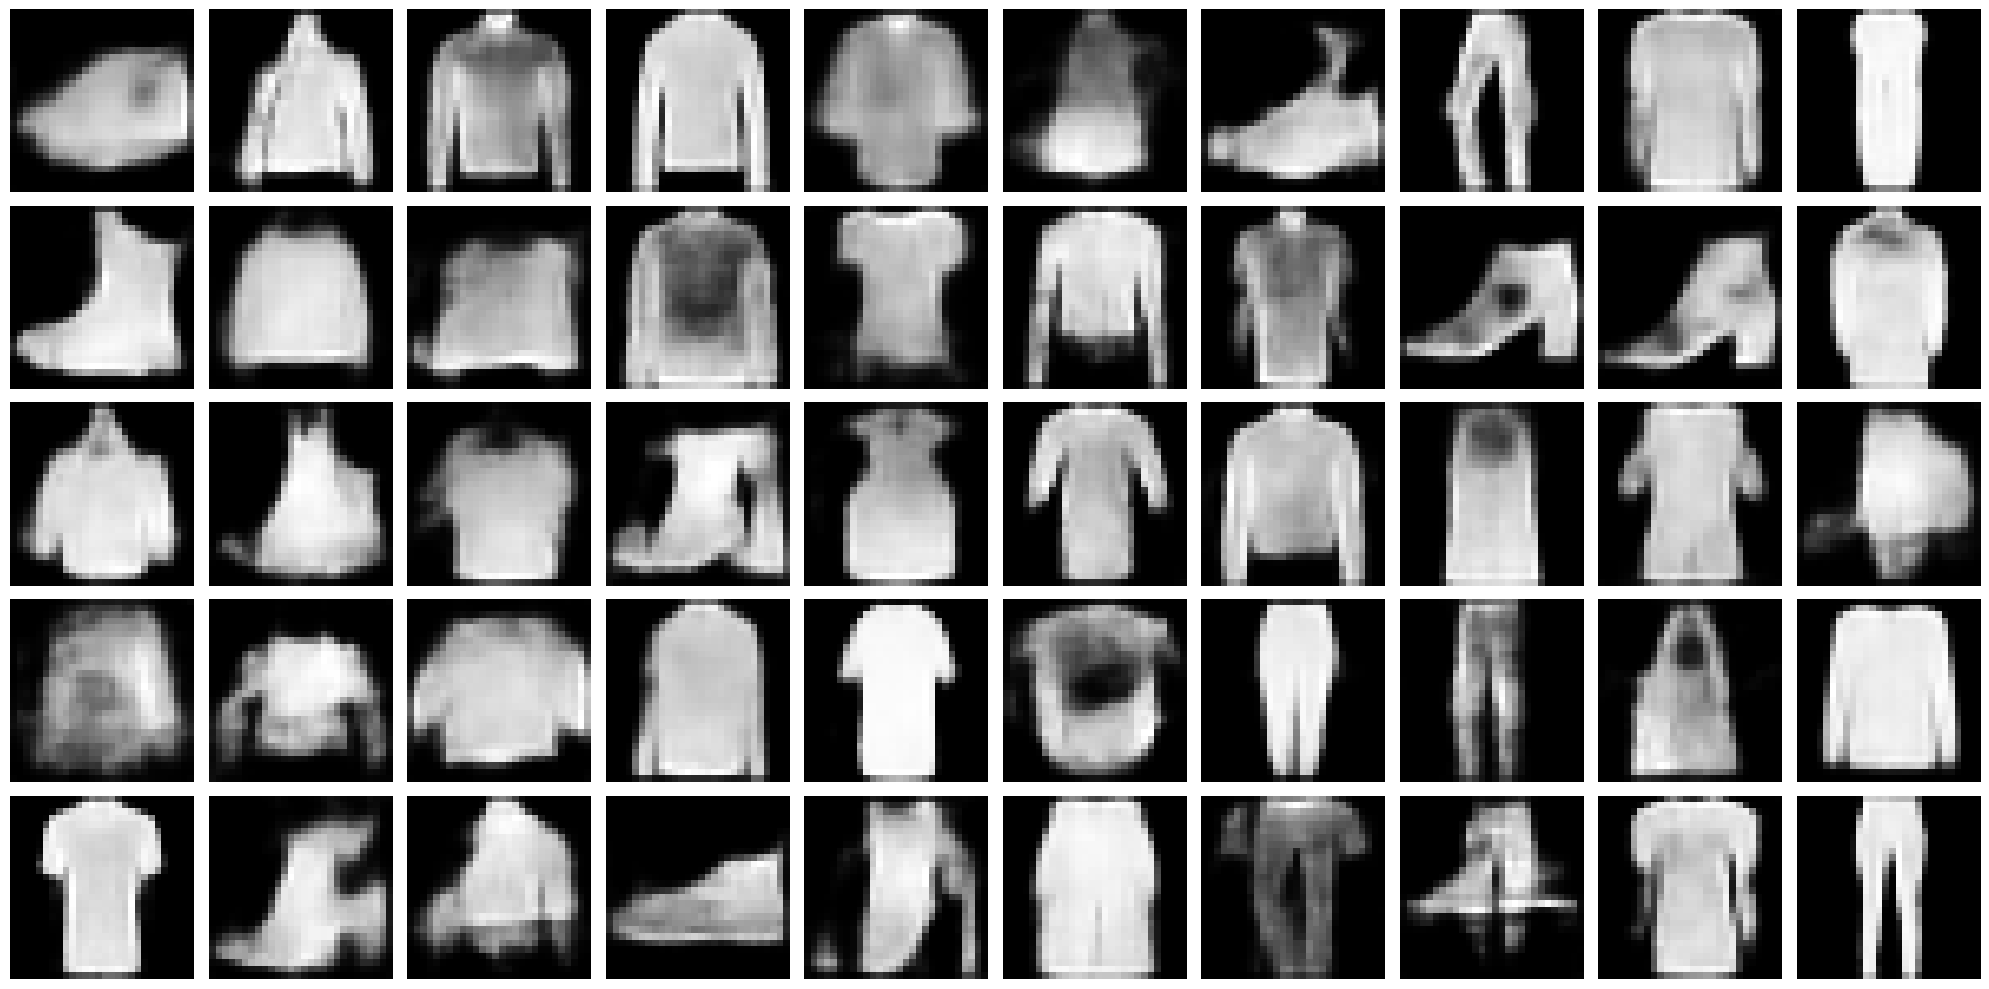


Sampling AFTER (Improved):


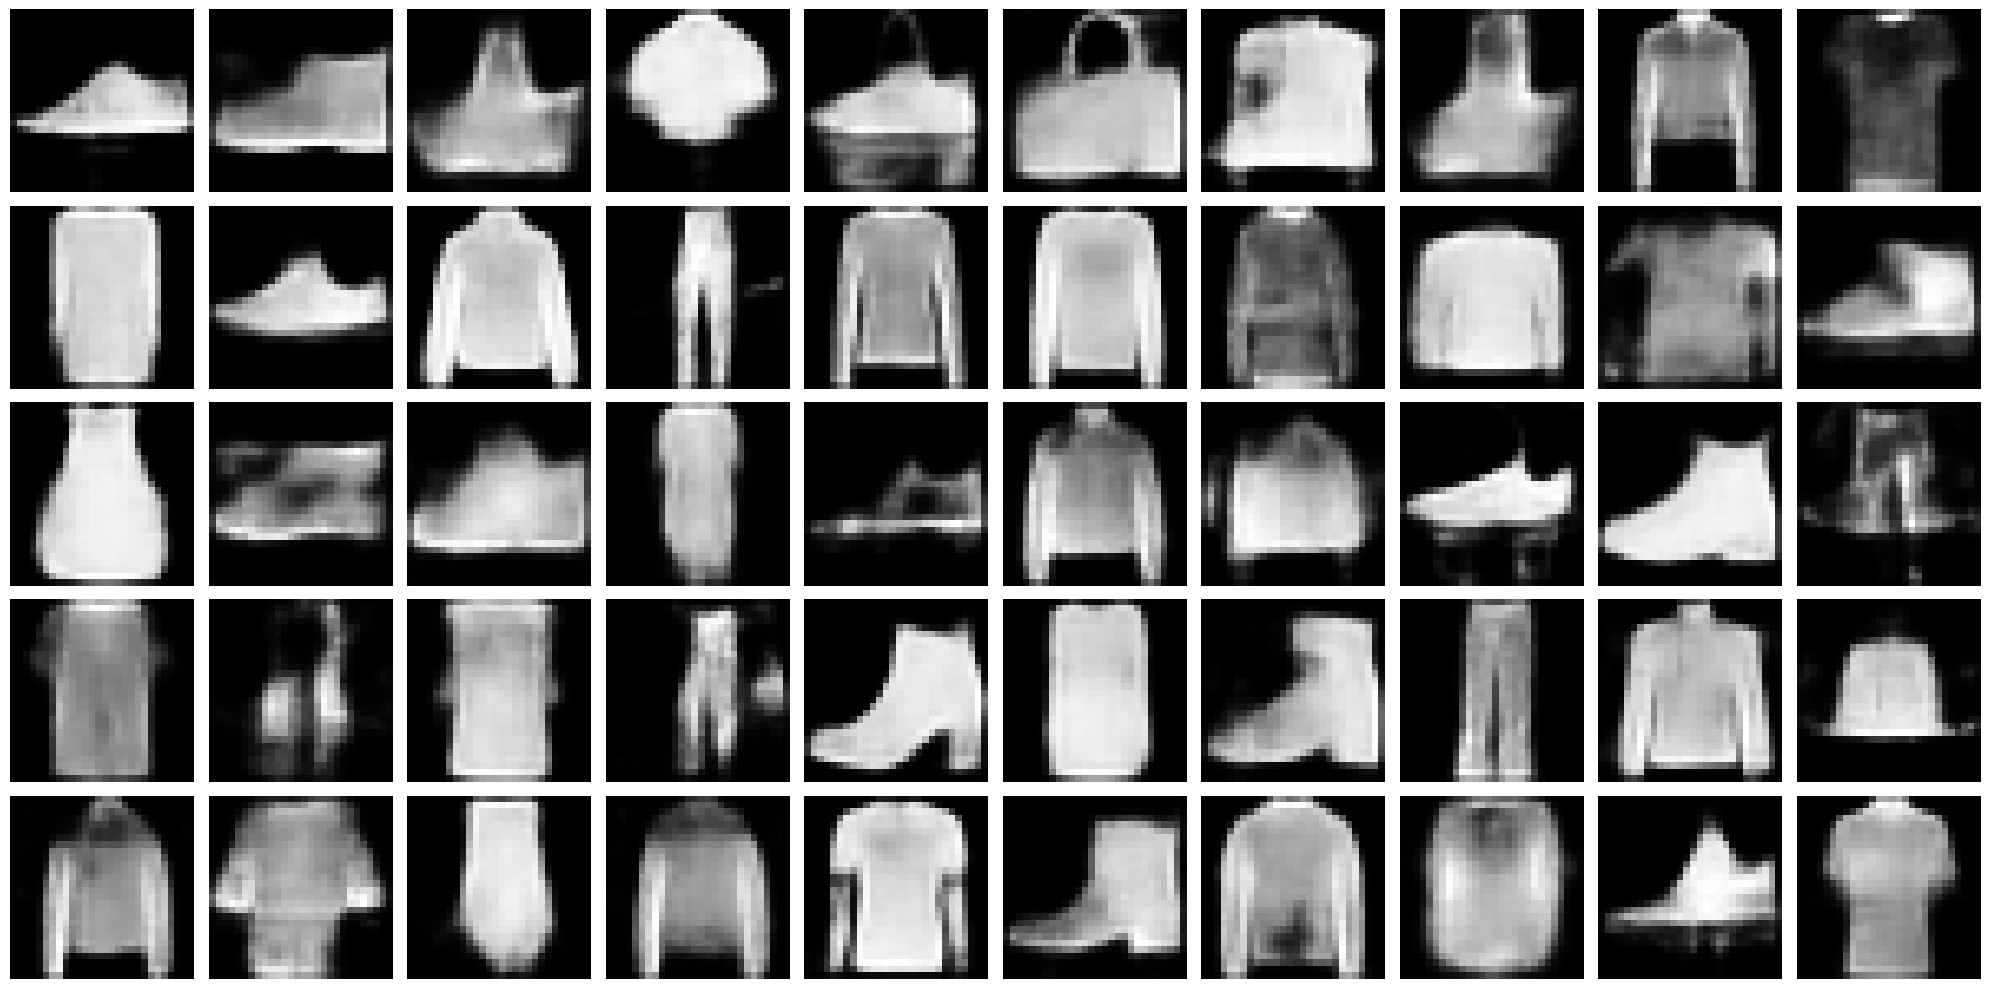

In [28]:
print("\nSampling BEFORE (Baseline):")
sample_from_prior(baseline_model, n=50, device=device)

print("\nSampling AFTER (Improved):")
sample_from_prior(improved_model, n=50, device=device)

 -----------------------------
### 6) Plot improved loss curves
 -----------------------------

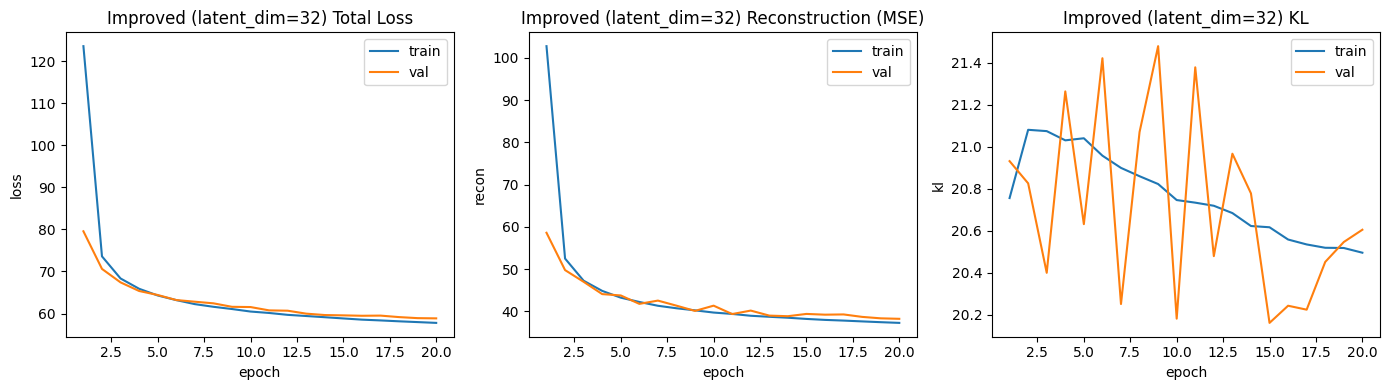

In [29]:
def plot_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train"]) + 1)

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, [h["loss"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["loss"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, [h["recon"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["recon"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Reconstruction (MSE)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, [h["kl"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["kl"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} KL")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(improved_history, title_prefix="Improved (latent_dim=32)")


## Phase 2 (Improvements): Multiple improved variants + 3-way comparison

 we add a COMBINED improvement:
   - latent_dim = 32
   - KL warm-up (beta annealing): beta 0 -> 1 over WARMUP_EPOCHS

 Finally we compare ALL THREE on TEST:
   - recon (MSE)
   - KL
   - total

In [30]:
def beta_linear_warmup(epoch, warmup_epochs=10, beta_max=1.0):
    return beta_max * min(1.0, epoch / warmup_epochs)

def train_with_beta_schedule(model, train_loader, val_loader, epochs, lr, device,
                             beta_max=1.0, warmup_epochs=0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        beta = beta_max if warmup_epochs == 0 else beta_linear_warmup(epoch, warmup_epochs, beta_max)

        train_m = run_epoch(model, train_loader, optimizer=opt, beta=beta, device=device)
        val_m   = run_epoch(model, val_loader, optimizer=None, beta=beta, device=device)

        history["train"].append({**train_m, "beta": beta})
        history["val"].append({**val_m, "beta": beta})

        print(
            f"Epoch {epoch:02d} (beta={beta:.3f}) | "
            f"train: loss={train_m['loss']:.4f}, recon={train_m['recon']:.4f}, kl={train_m['kl']:.4f} | "
            f"val: loss={val_m['loss']:.4f}, recon={val_m['recon']:.4f}, kl={val_m['kl']:.4f}"
        )

    return history

def print_test_table_3(results_dict):
    print("\nTEST SET METRICS TABLE (3-way comparison)")
    print("-" * 110)
    header = f"{'Model':<16} {'latent_dim':<10} {'beta':<8} {'policy':<20} {'recon(MSE)':<14} {'KL':<14} {'total':<14}"
    print(header)
    print("-" * 110)
    for name, r in results_dict.items():
        print(f"{name:<16} {r['latent_dim']:<10d} {r['beta']:<8.3f} {r['policy']:<20} "
              f"{r['recon']:<14.6f} {r['kl']:<14.6f} {r['loss']:<14.6f}")
    print("-" * 110)

In [31]:
baseline_model = copy.deepcopy(model).to(device)
baseline_latent = baseline_model.latent_dim
baseline_beta_eval = 1.0

baseline_test = run_epoch(baseline_model, test_loader, optimizer=None, beta=baseline_beta_eval, device=device)
print("\n[A] Baseline (latent_dim={}, beta=1 const) TEST:".format(baseline_latent))
print(baseline_test)

improved1_model = copy.deepcopy(improved_model).to(device)
improved1_latent = improved1_model.latent_dim
improved1_beta_eval = 1.0

improved1_test = run_epoch(improved1_model, test_loader, optimizer=None, beta=improved1_beta_eval, device=device)
print("\n[B] Improved-1 (latent_dim={}, beta=1 const) TEST:".format(improved1_latent))
print(improved1_test)


[A] Baseline (latent_dim=16, beta=1 const) TEST:
{'loss': 58.18606712244734, 'recon': 38.49576307852057, 'kl': 19.690304068070425}

[B] Improved-1 (latent_dim=64, beta=1 const) TEST:
{'loss': 58.844157979458195, 'recon': 38.33427545088756, 'kl': 20.50988243199602}


### MODEL C: Combined improvement (latent_dim=32 + KL warm-up)

In [72]:
COMB_LATENT_DIM = 32
COMB_EPOCHS = EPOCHS
COMB_LR = LR
COMB_BETA_MAX = 1.0
WARMUP_EPOCHS = 10

combined_model = ConvVAE(latent_dim=COMB_LATENT_DIM).to(device)

print("\n[C] Training Combined Improvement: latent_dim=32 + KL warm-up (0->1 over {} epochs)".format(WARMUP_EPOCHS))
combined_history = train_with_beta_schedule(
    combined_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=COMB_EPOCHS,
    lr=COMB_LR,
    device=device,
    beta_max=COMB_BETA_MAX,
    warmup_epochs=WARMUP_EPOCHS
)

combined_beta_eval = 1.0
combined_test = run_epoch(combined_model, test_loader, optimizer=None, beta=combined_beta_eval, device=device)

print("\n[C] Combined Improvement TEST (eval beta=1):")
print(combined_test)


[C] Training Combined Improvement: latent_dim=32 + KL warm-up (0->1 over 10 epochs)
Epoch 01 (beta=0.100) | train: loss=87.4772, recon=80.9371, kl=65.4008 | val: loss=46.1362, recon=39.1294, kl=70.0675
Epoch 02 (beta=0.200) | train: loss=47.2258, recon=35.8603, kl=56.8276 | val: loss=44.7237, recon=33.4878, kl=56.1795
Epoch 03 (beta=0.300) | train: loss=47.8144, recon=33.2906, kl=48.4127 | val: loss=46.6873, recon=32.1369, kl=48.5016
Epoch 04 (beta=0.400) | train: loss=49.8378, recon=33.1282, kl=41.7742 | val: loss=49.6284, recon=32.5906, kl=42.5945
Epoch 05 (beta=0.500) | train: loss=52.1875, recon=33.9311, kl=36.5127 | val: loss=51.9512, recon=34.2038, kl=35.4946
Epoch 06 (beta=0.600) | train: loss=54.3478, recon=34.8074, kl=32.5673 | val: loss=54.4286, recon=34.5353, kl=33.1555
Epoch 07 (beta=0.700) | train: loss=56.4302, recon=35.8899, kl=29.3432 | val: loss=56.6291, recon=36.4358, kl=28.8476
Epoch 08 (beta=0.800) | train: loss=58.3031, recon=36.8430, kl=26.8252 | val: loss=58.986

Load classifier and build a feature extractor

In [63]:
import torch
import torch.nn as nn
import numpy as np
from torchvision import models

CLASSIFIER_PATH = "./fashion_resnet18_classifier.pt"
NUM_CLASSES = 10

def build_resnet18_1ch(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def strip_prefix(state_dict, prefix):
    out = {}
    for k, v in state_dict.items():
        if k.startswith(prefix):
            out[k[len(prefix):]] = v
        else:
            out[k] = v
    return out

# ---- load ckpt
ckpt = torch.load(CLASSIFIER_PATH, map_location="cpu")
clf_mean = ckpt["mean"]  # tuple like (0.286,)
clf_std = ckpt["std"]    # tuple like (0.353,)
feature_dim = ckpt.get("feature_dim", None)

state = ckpt["model_state_dict"]
state = strip_prefix(state, "backbone.")
if "head.weight" in state and "head.bias" in state:
    state["fc.weight"] = state.pop("head.weight")
    state["fc.bias"] = state.pop("head.bias")

classifier = build_resnet18_1ch(num_classes=NUM_CLASSES).to(device)
missing, unexpected = classifier.load_state_dict(state, strict=False)
classifier.eval()

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
print("mean/std:", clf_mean, clf_std, "feature_dim:", feature_dim)

# ---- feature extractor: everything except final fc
# output shape: (B, 512) for resnet18
feature_extractor = nn.Sequential(*(list(classifier.children())[:-1])).to(device)
feature_extractor.eval()

Missing keys: []
Unexpected keys: []
mean/std: (0.286,) (0.353,) feature_dim: 512


Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Identity()
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

In [64]:
def preprocess_for_classifier(x, mean, std, device="cuda"):
    """
    x: tensor in [-1,1], shape (B,1,28,28)
    classifier expects: normalize((x in [0,1]) with mean/std from ckpt)
    """
    x01 = (x + 1.0) / 2.0  # [-1,1] -> [0,1]
    mean_t = torch.tensor(mean, device=device).view(1,1,1,1)
    std_t  = torch.tensor(std, device=device).view(1,1,1,1)
    return (x01 - mean_t) / std_t

Extract features from a loader (real test images)

In [65]:
@torch.no_grad()
def extract_features_from_loader(feature_extractor, loader, mean, std, device="cuda", max_images=None):
    feats = []
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_in = preprocess_for_classifier(x, mean, std, device=device)
        f = feature_extractor(x_in).flatten(1)  # (B,512)
        feats.append(f.cpu())
        n += x.size(0)
        if max_images is not None and n >= max_images:
            break
    feats = torch.cat(feats, dim=0)
    if max_images is not None:
        feats = feats[:max_images]
    return feats.numpy()

Sample 10,000 images from a VAE (generated images)

In [66]:
@torch.no_grad()
def sample_images_from_vae(model, n=10000, batch_size=256, device="cuda"):
    model.eval()
    xs = []
    remaining = n
    while remaining > 0:
        b = min(batch_size, remaining)
        z = torch.randn(b, model.latent_dim, device=device)
        x = model.decode(z)  # in [-1,1]
        xs.append(x.cpu())
        remaining -= b
    return torch.cat(xs, dim=0)  # (n,1,28,28)

@torch.no_grad()
def extract_features_from_generated(feature_extractor, x_gen, mean, std, device="cuda", batch_size=256):
    feats = []
    n = x_gen.size(0)
    for i in range(0, n, batch_size):
        x = x_gen[i:i+batch_size].to(device)
        x_in = preprocess_for_classifier(x, mean, std, device=device)
        f = feature_extractor(x_in).flatten(1)
        feats.append(f.cpu())
    feats = torch.cat(feats, dim=0)
    return feats.numpy()

Compute FID (Frechet distance)

In [67]:
import numpy as np
from scipy import linalg

def compute_fid(feats_real, feats_fake, eps=1e-6):
    """
    feats_real, feats_fake: np arrays shape (N, D)
    """
    mu_r = np.mean(feats_real, axis=0)
    mu_f = np.mean(feats_fake, axis=0)

    cov_r = np.cov(feats_real, rowvar=False)
    cov_f = np.cov(feats_fake, rowvar=False)

    diff = mu_r - mu_f

    # sqrtm of product
    covmean, _ = linalg.sqrtm(cov_r.dot(cov_f), disp=False)
    if not np.isfinite(covmean).all():
        cov_r += np.eye(cov_r.shape[0]) * eps
        cov_f += np.eye(cov_f.shape[0]) * eps
        covmean = linalg.sqrtm(cov_r.dot(cov_f))

    # handle numerical complex result
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(cov_r + cov_f - 2.0 * covmean)
    return float(fid)

### comparing the results:

In [33]:
results = {
    "A_baseline": {
        "latent_dim": baseline_latent,
        "beta": baseline_beta_eval,
        "policy": "const",
        **baseline_test
    },
    "B_improved1": {
        "latent_dim": improved1_latent,
        "beta": improved1_beta_eval,
        "policy": "const",
        **improved1_test
    },
    "C_combined": {
        "latent_dim": COMB_LATENT_DIM,
        "beta": combined_beta_eval,
        "policy": f"warmup(0->1,{WARMUP_EPOCHS})",
        **combined_test
    },
}

print_test_table_3(results)


TEST SET METRICS TABLE (3-way comparison)
--------------------------------------------------------------------------------------------------------------
Model            latent_dim beta     policy               recon(MSE)     KL             total         
--------------------------------------------------------------------------------------------------------------
A_baseline       16         1.000    const                38.495763      19.690304      58.186067     
B_improved1      64         1.000    const                38.334275      20.509882      58.844158     
C_combined       32         1.000    warmup(0->1,10)      37.041904      22.225591      59.267495     
--------------------------------------------------------------------------------------------------------------



Reconstructions — A (Baseline)


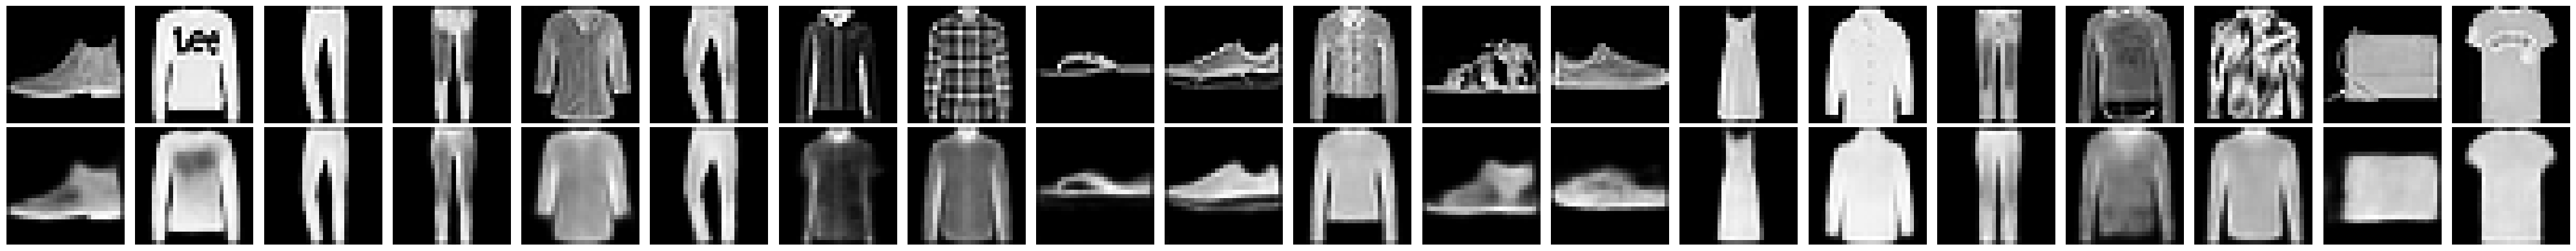


Reconstructions — B (Improved-1)


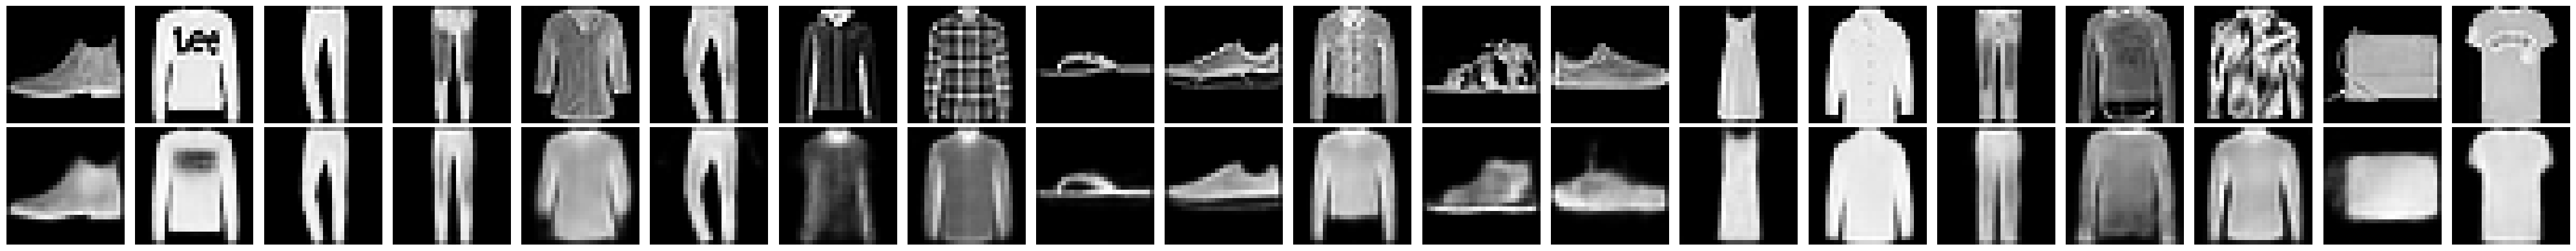


Reconstructions — C (Combined improvement)


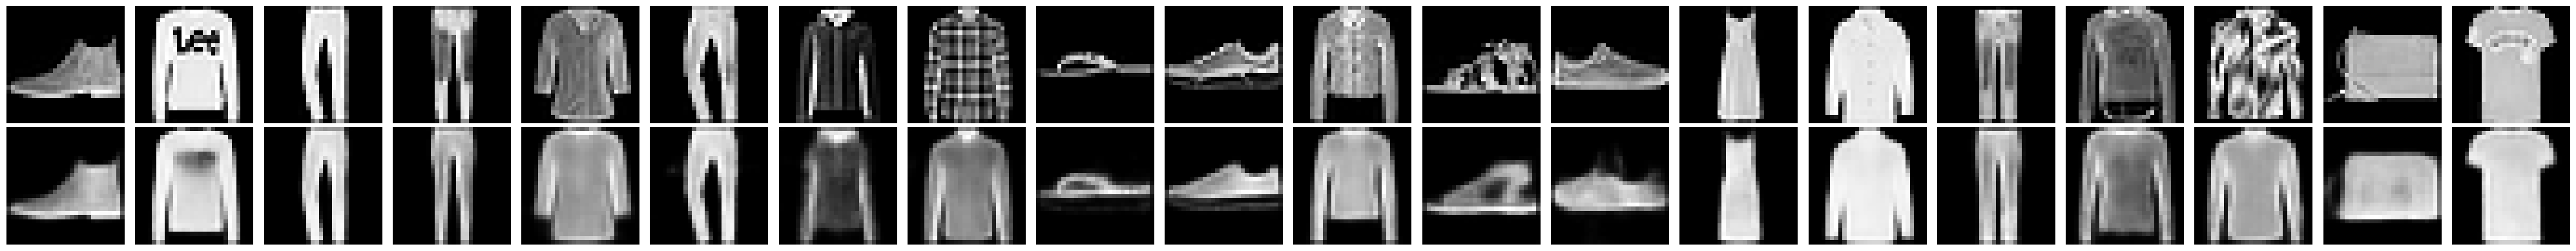

In [34]:
print("\nReconstructions — A (Baseline)")
show_reconstructions(baseline_model, test_loader, n=20, device=device)

print("\nReconstructions — B (Improved-1)")
show_reconstructions(improved1_model, test_loader, n=20, device=device)

print("\nReconstructions — C (Combined improvement)")
show_reconstructions(combined_model, test_loader, n=20, device=device)


Sampling — A (Baseline)


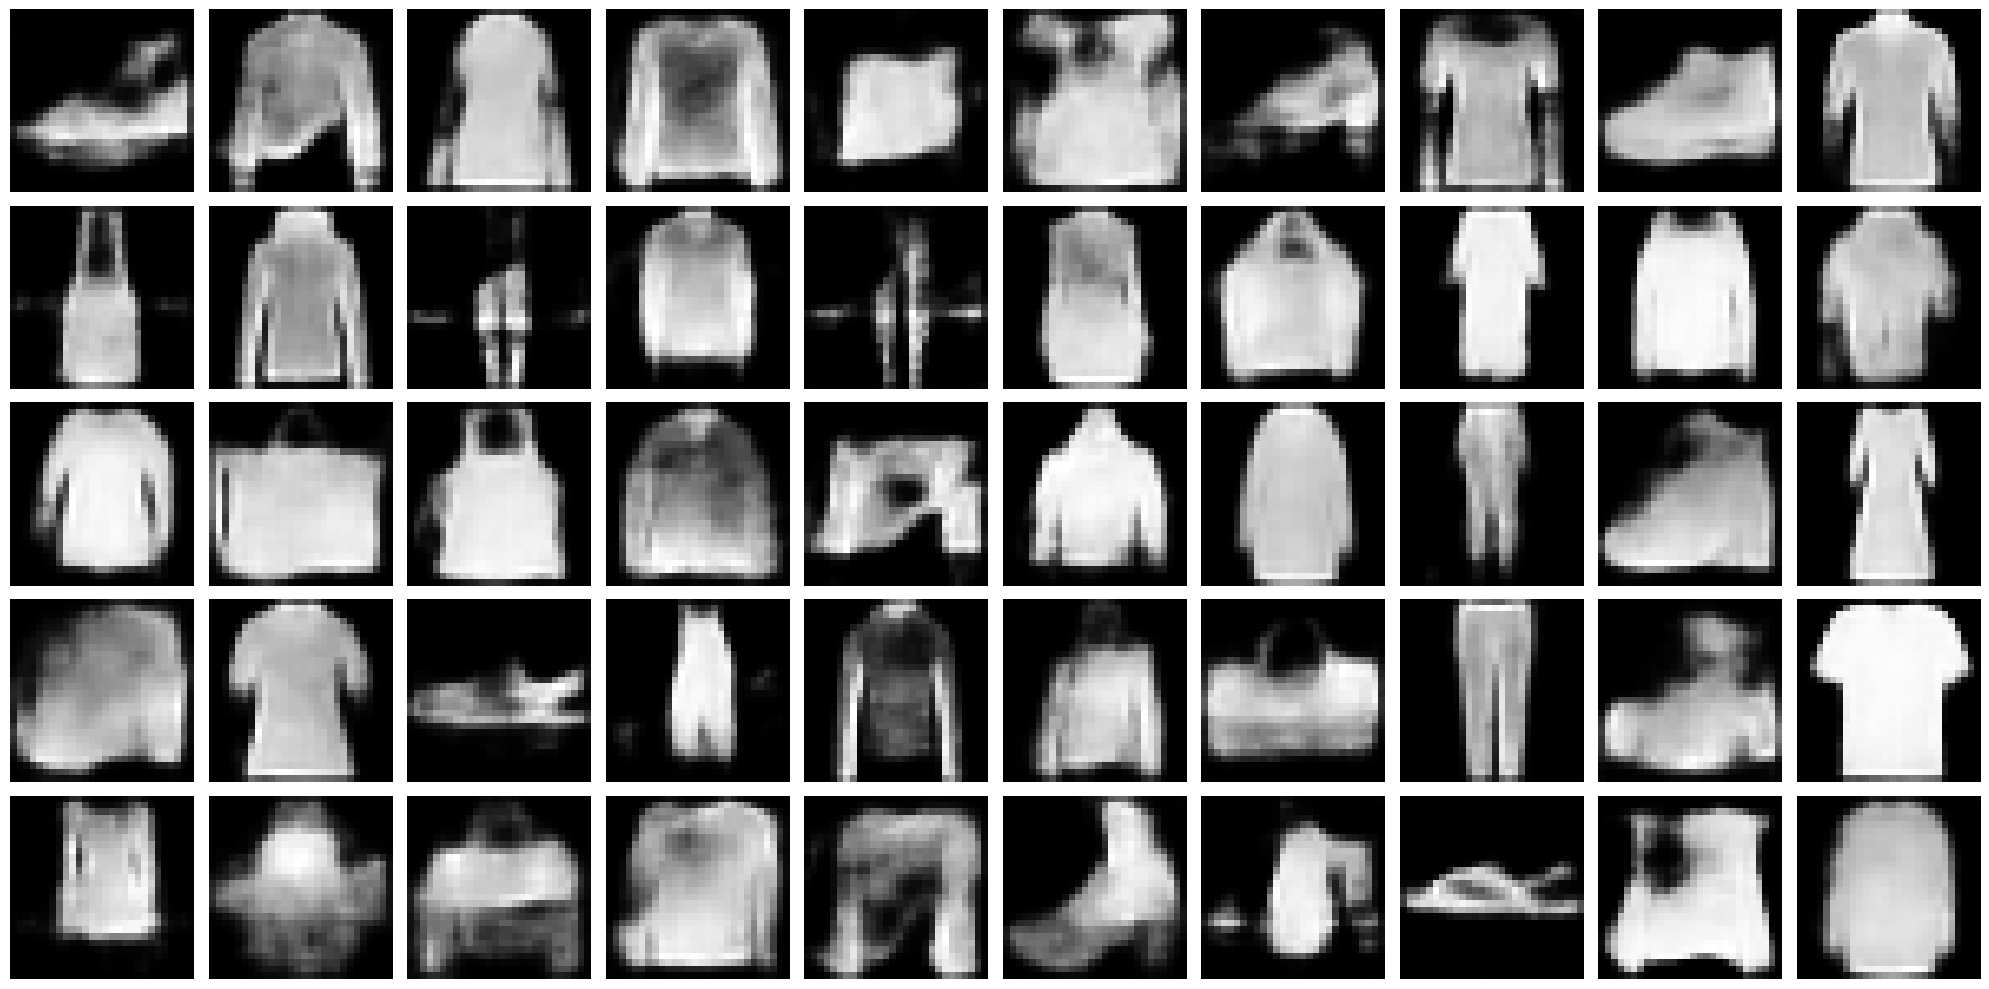


Sampling — B (Improved-1)


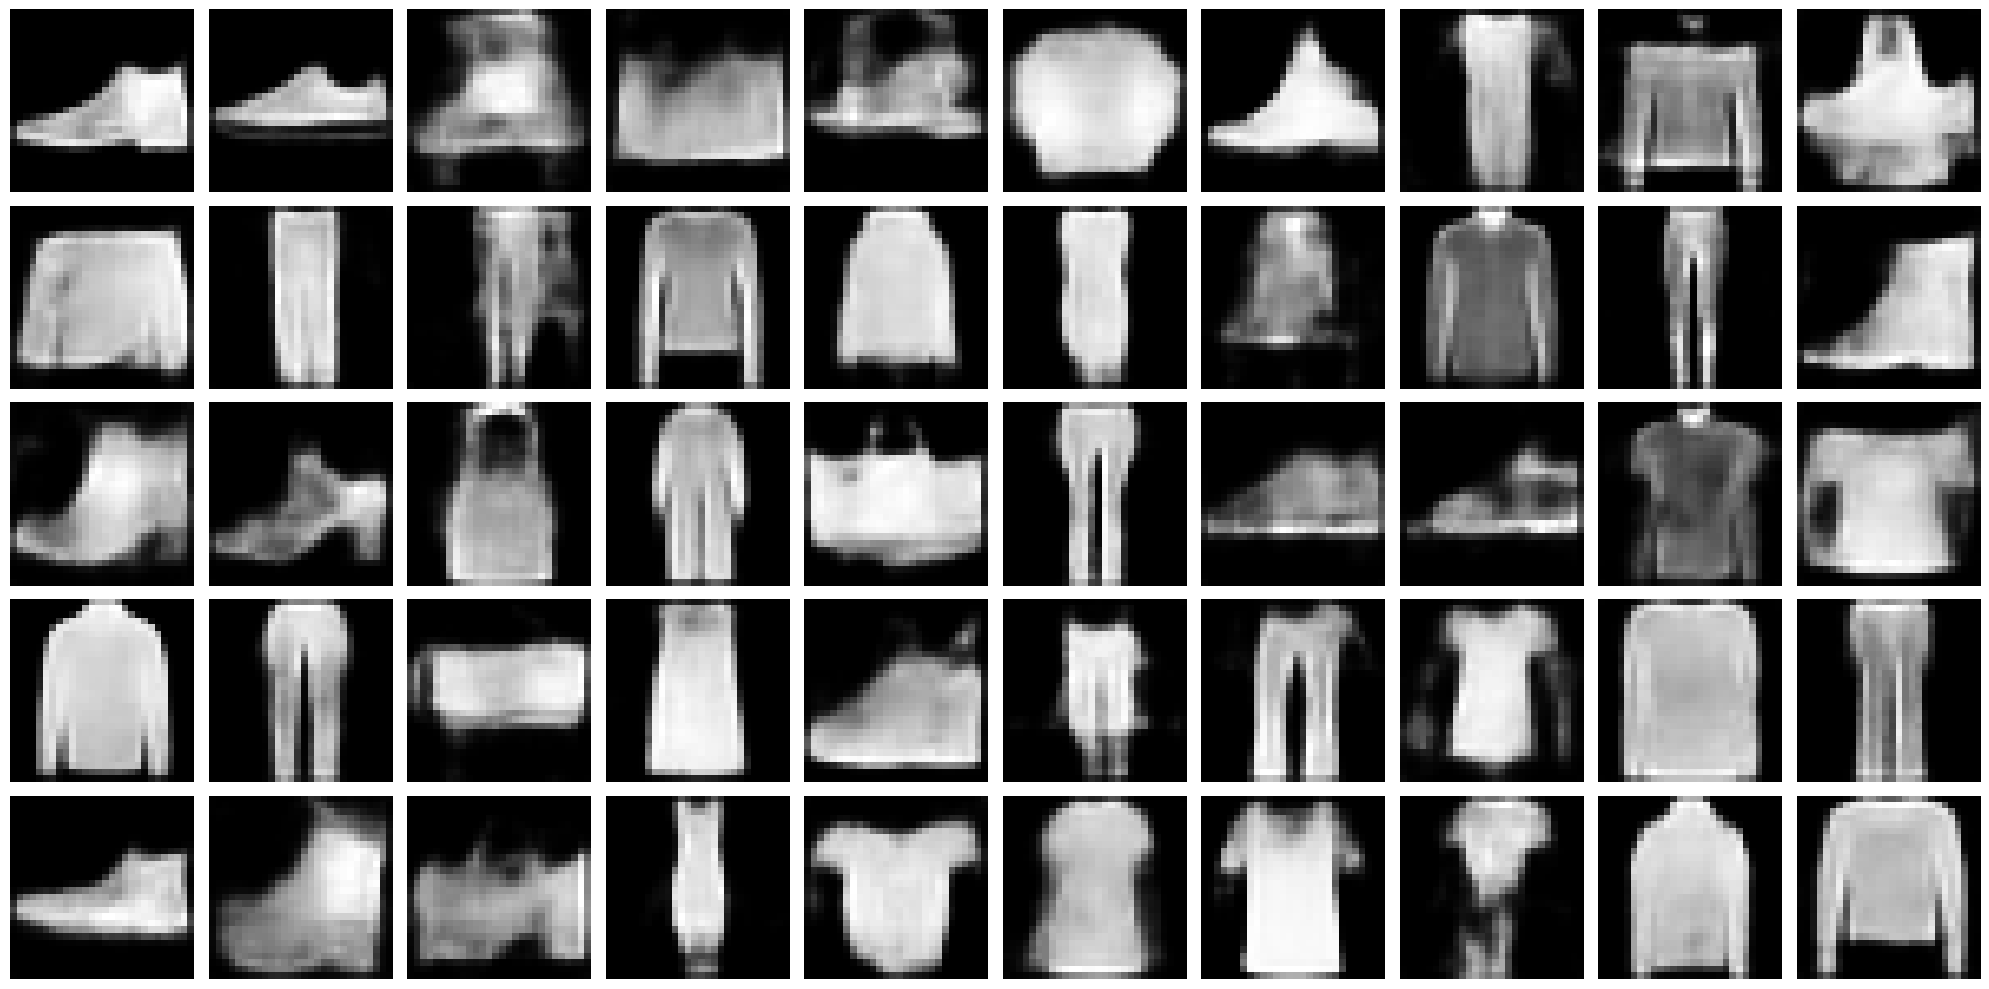


Sampling — C (Combined improvement)


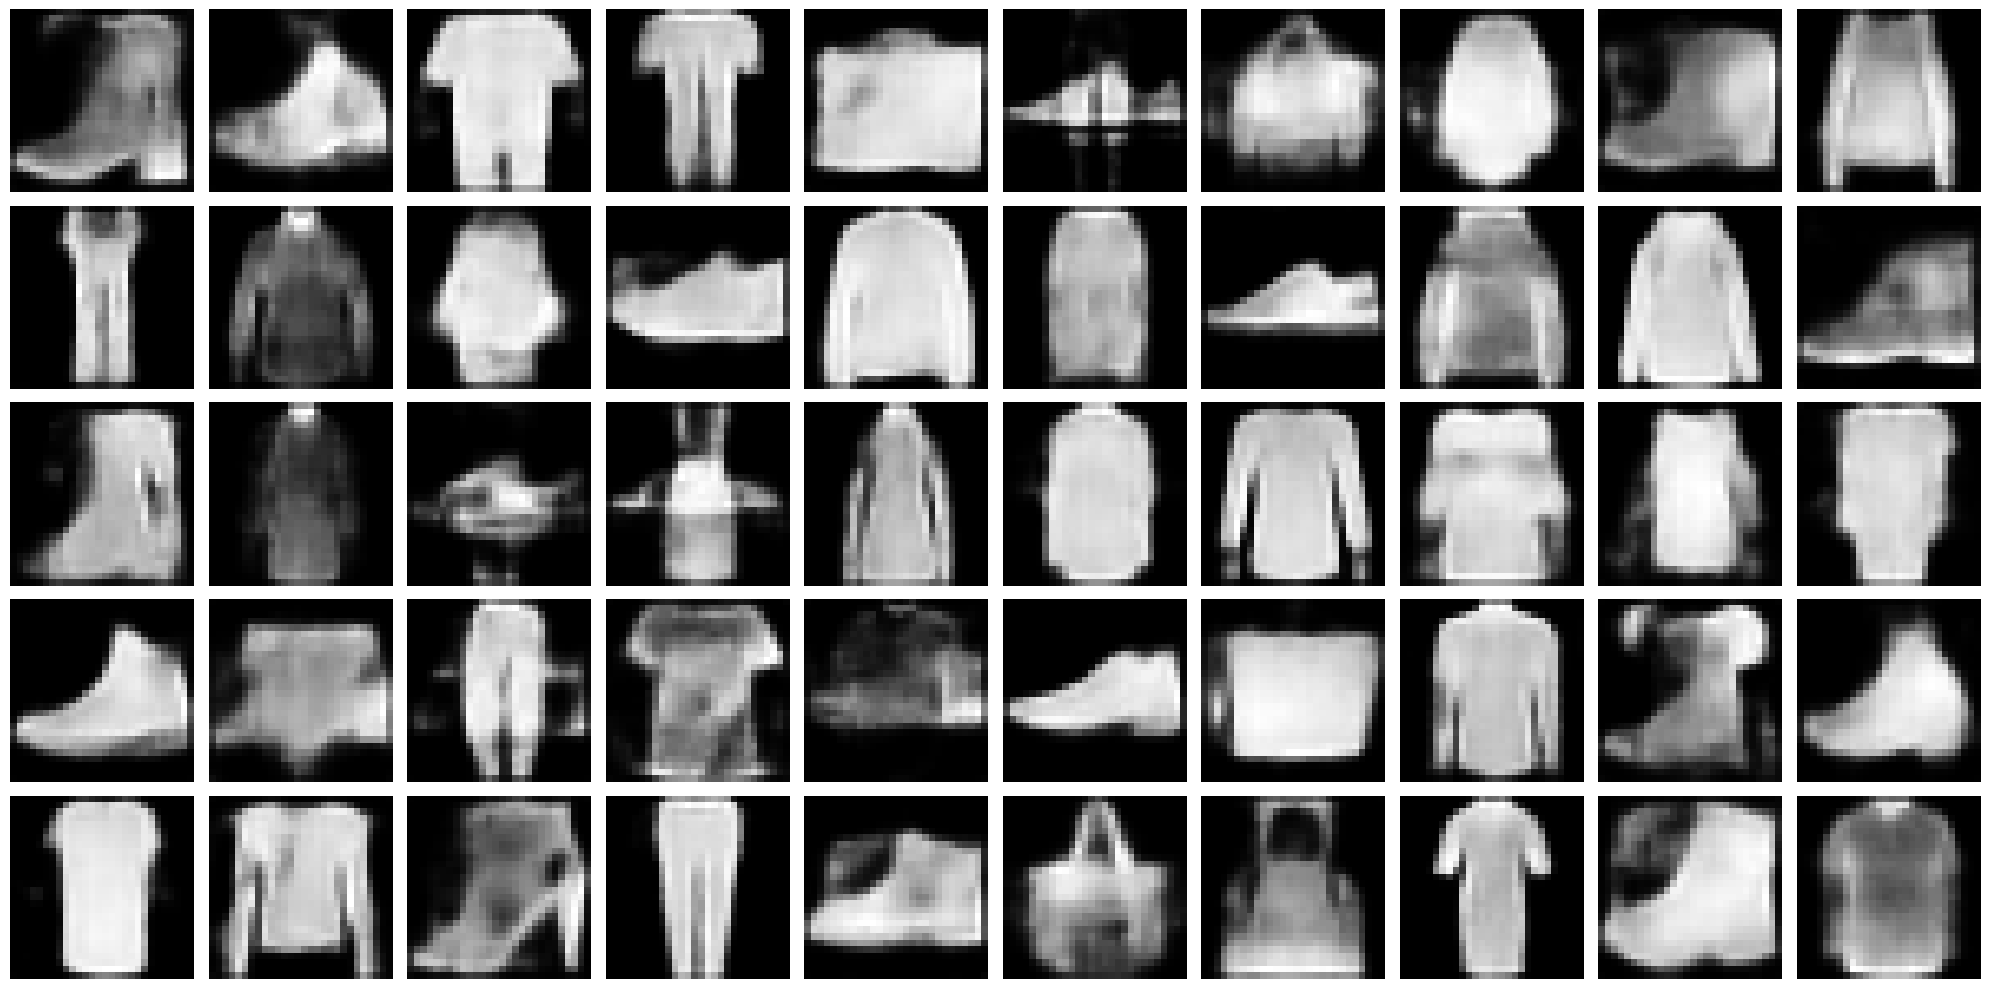

In [35]:
print("\nSampling — A (Baseline)")
sample_from_prior(baseline_model, n=50, device=device)

print("\nSampling — B (Improved-1)")
sample_from_prior(improved1_model, n=50, device=device)

print("\nSampling — C (Combined improvement)")
sample_from_prior(combined_model, n=50, device=device)

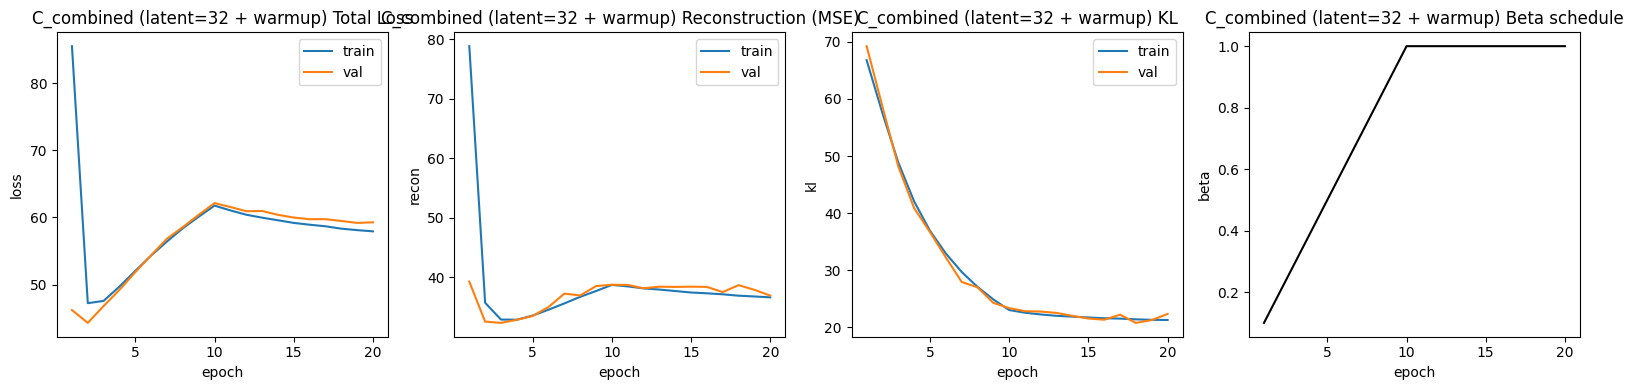

In [36]:
def plot_combined_history(history, title_prefix="Combined"):
    epochs = np.arange(1, len(history["train"]) + 1)
    betas = [h["beta"] for h in history["train"]]

    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.plot(epochs, [h["loss"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["loss"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1,4,2)
    plt.plot(epochs, [h["recon"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["recon"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Reconstruction (MSE)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    plt.subplot(1,4,3)
    plt.plot(epochs, [h["kl"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["kl"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} KL")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.subplot(1,4,4)
    plt.plot(epochs, betas, color="black")
    plt.title(f"{title_prefix} Beta schedule")
    plt.xlabel("epoch"); plt.ylabel("beta")

    plt.tight_layout()
    plt.show()

plot_combined_history(combined_history, title_prefix="C_combined (latent=32 + warmup)")

 Run FID for A/B/C and print a table


In [69]:
feats_test = extract_features_from_loader(
    feature_extractor, test_loader, mean=clf_mean, std=clf_std, device=device, max_images=10000
)
print("Real test features:", feats_test.shape)

def fid_for_model(name, vae_model, n_gen=10000):
    x_gen = sample_images_from_vae(vae_model, n=n_gen, batch_size=256, device=device)
    feats_gen = extract_features_from_generated(
        feature_extractor, x_gen, mean=clf_mean, std=clf_std, device=device, batch_size=256
    )
    fid = compute_fid(feats_test, feats_gen)
    print(f"{name}: FID={fid:.4f}")
    return fid

# Make sure these variables exist from your Phase-2 section:
# baseline_model, improved1_model, combined_model
fid_A = fid_for_model("A_baseline", baseline_model, n_gen=10000)
fid_B = fid_for_model("B_improved1", improved1_model, n_gen=10000)
fid_C = fid_for_model("C_combined", combined_model, n_gen=10000)

print("\nFID TABLE (lower is better)")
print("-"*50)
print(f"{'Model':<14} {'FID':<10}")
print("-"*50)
print(f"{'A_baseline':<14} {fid_A:<10.4f}")
print(f"{'B_improved1':<14} {fid_B:<10.4f}")
print(f"{'C_combined':<14} {fid_C:<10.4f}")
print("-"*50)

Real test features: (10000, 512)


/tmp/ipython-input-556831324.py:17: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r.dot(cov_f), disp=False)


A_baseline: FID=28.7348
B_improved1: FID=32.6871
C_combined: FID=33.7668

FID TABLE (lower is better)
--------------------------------------------------
Model          FID       
--------------------------------------------------
A_baseline     28.7348   
B_improved1    32.6871   
C_combined     33.7668   
--------------------------------------------------


In [74]:
C_EPOCHS = 10
C_LR = LR
C_LATENT_DIM = 16                 # keep same as baseline to isolate beta effect
BETA_CANDIDATES = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

best_fid = float("inf")
best_beta = None
best_model = None
best_test = None

print("\n[C] Training FID-driven Improvement: beta sweep, selecting lowest FID...")

for beta in BETA_CANDIDATES:
    print("\n" + "-"*70)
    print(f"[C-candidate] beta={beta}")

    m = ConvVAE(latent_dim=C_LATENT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=C_LR)

    for epoch in range(1, C_EPOCHS + 1):
        tr = run_epoch(m, train_loader, optimizer=opt, beta=beta, device=device)
        va = run_epoch(m, val_loader, optimizer=None, beta=beta, device=device)
        print(f"Epoch {epoch:02d} | train loss={tr['loss']:.4f} recon={tr['recon']:.4f} kl={tr['kl']:.4f} | "
              f"val loss={va['loss']:.4f} recon={va['recon']:.4f} kl={va['kl']:.4f}")

    test_m = run_epoch(m, test_loader, optimizer=None, beta=beta, device=device)

    fid = fid_for_model("", m)

    print(f"[beta={beta}] TEST: recon={test_m['recon']:.6f}, kl={test_m['kl']:.6f}, total={test_m['loss']:.6f} | FID={fid:.4f}")

    if fid < best_fid:
        best_fid = fid
        best_beta = beta
        best_model = m
        best_test = test_m

combined_model = best_model
combined_test = best_test
combined_beta_eval = best_beta

print("\n[C] Selected BEST-FID model")
print(f"Best beta = {best_beta} | Best FID = {best_fid:.4f}")
print("[C] Best-FID TEST metrics:")
print(combined_test)


[C] Training FID-driven Improvement: beta sweep, selecting lowest FID...

----------------------------------------------------------------------
[C-candidate] beta=0.25
Epoch 01 | train loss=91.7238 recon=83.0468 kl=34.7083 | val loss=53.8839 recon=44.7617 kl=36.4887
Epoch 02 | train loss=49.3650 recon=40.2813 kl=36.3348 | val loss=47.0609 recon=37.9419 kl=36.4760
Epoch 03 | train loss=45.2550 recon=36.1816 kl=36.2936 | val loss=44.2570 recon=35.2355 kl=36.0861
Epoch 04 | train loss=43.3103 recon=34.2374 kl=36.2917 | val loss=42.9048 recon=33.8726 kl=36.1287
Epoch 05 | train loss=41.9609 recon=32.8855 kl=36.3016 | val loss=42.4193 recon=32.9381 kl=37.9246
Epoch 06 | train loss=41.1105 recon=32.0407 kl=36.2792 | val loss=41.4766 recon=32.4676 kl=36.0361
Epoch 07 | train loss=40.4350 recon=31.3708 kl=36.2567 | val loss=41.1054 recon=32.4512 kl=34.6168
Epoch 08 | train loss=39.9171 recon=30.8711 kl=36.1837 | val loss=40.8629 recon=32.0400 kl=35.2915
Epoch 09 | train loss=39.5515 recon=30

/tmp/ipython-input-556831324.py:17: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r.dot(cov_f), disp=False)


: FID=52.1211
[beta=0.25] TEST: recon=31.270762, kl=36.167442, total=40.312623 | FID=52.1211

----------------------------------------------------------------------
[C-candidate] beta=0.5
Epoch 01 | train loss=102.4298 recon=89.2379 kl=26.3839 | val loss=62.5552 recon=48.4807 kl=28.1490
Epoch 02 | train loss=57.9998 recon=43.9506 kl=28.0985 | val loss=55.1174 recon=40.9005 kl=28.4337
Epoch 03 | train loss=53.3954 recon=39.3173 kl=28.1562 | val loss=52.6239 recon=38.8507 kl=27.5465
Epoch 04 | train loss=51.4542 recon=37.3579 kl=28.1926 | val loss=51.2206 recon=37.2712 kl=27.8988
Epoch 05 | train loss=50.1655 recon=36.0875 kl=28.1559 | val loss=50.2696 recon=36.2608 kl=28.0177
Epoch 06 | train loss=49.2838 recon=35.2143 kl=28.1389 | val loss=49.4958 recon=35.5021 kl=27.9873
Epoch 07 | train loss=48.6519 recon=34.5791 kl=28.1456 | val loss=49.2053 recon=34.9601 kl=28.4905
Epoch 08 | train loss=48.1048 recon=34.0703 kl=28.0690 | val loss=48.6584 recon=35.0919 kl=27.1329
Epoch 09 | train lo

## Phase 3 — β-VAE: Regularization Weight Sweep + Latent Traversal

In [37]:
# Config
BETAS = [0.5, 1.0, 4.0]
LATENT_DIM_PHASE3 = 16
EPOCHS_PHASE3 = 20
LR_PHASE3 = 1e-3

TRAVERSAL_DIMS = 5
TRAVERSAL_STEPS = 7
TRAVERSAL_VALUES = np.linspace(-3, 3, TRAVERSAL_STEPS)
N_TRAVERSAL_SAMPLES = 1


### (1) Train β‑VAE models and evaluate on TEST (table)

In [38]:
def train_beta_vae(beta, latent_dim, epochs, lr, device):
    model = ConvVAE(latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {"train": [], "val": []}
    for epoch in range(1, epochs + 1):
        train_m = run_epoch(model, train_loader, optimizer=opt, beta=beta, device=device)
        val_m   = run_epoch(model, val_loader, optimizer=None, beta=beta, device=device)

        hist["train"].append(train_m)
        hist["val"].append(val_m)

        print(f"[beta={beta}] Epoch {epoch:02d} | "
              f"train loss={train_m['loss']:.4f} recon={train_m['recon']:.4f} kl={train_m['kl']:.4f} | "
              f"val loss={val_m['loss']:.4f} recon={val_m['recon']:.4f} kl={val_m['kl']:.4f}")

    return model, hist


beta_models = {}
beta_histories = {}
beta_test_metrics = {}

for b in BETAS:
    print("\n" + "="*80)
    print(f"Training Beta-VAE with beta = {b}")
    print("="*80)

    m, h = train_beta_vae(
        beta=b,
        latent_dim=LATENT_DIM_PHASE3,
        epochs=EPOCHS_PHASE3,
        lr=LR_PHASE3,
        device=device
    )

    beta_models[b] = m
    beta_histories[b] = h

    test_m = run_epoch(m, test_loader, optimizer=None, beta=b, device=device)
    beta_test_metrics[b] = test_m

print("\nTEST SET METRICS TABLE (Phase 3)")
print("-"*80)
print(f"{'beta':<6} {'recon(MSE)':<14} {'KL':<14} {'total':<14}")
print("-"*80)
for b in BETAS:
    tm = beta_test_metrics[b]
    print(f"{b:<6.2f} {tm['recon']:<14.6f} {tm['kl']:<14.6f} {tm['loss']:<14.6f}")
print("-"*80)


Training Beta-VAE with beta = 0.5
[beta=0.5] Epoch 01 | train loss=101.3645 recon=88.4686 kl=25.7918 | val loss=62.5141 recon=48.2132 kl=28.6017
[beta=0.5] Epoch 02 | train loss=57.6345 recon=43.6258 kl=28.0173 | val loss=55.5261 recon=41.9696 kl=27.1131
[beta=0.5] Epoch 03 | train loss=53.4706 recon=39.4341 kl=28.0730 | val loss=52.8039 recon=38.6771 kl=28.2536
[beta=0.5] Epoch 04 | train loss=51.4362 recon=37.4085 kl=28.0554 | val loss=51.5814 recon=37.5945 kl=27.9738
[beta=0.5] Epoch 05 | train loss=50.1499 recon=36.1016 kl=28.0967 | val loss=50.3579 recon=36.4657 kl=27.7845
[beta=0.5] Epoch 06 | train loss=49.2257 recon=35.2276 kl=27.9961 | val loss=50.0747 recon=35.8067 kl=28.5361
[beta=0.5] Epoch 07 | train loss=48.5358 recon=34.5197 kl=28.0323 | val loss=49.3934 recon=34.9938 kl=28.7993
[beta=0.5] Epoch 08 | train loss=47.9835 recon=34.0006 kl=27.9658 | val loss=48.6458 recon=34.2240 kl=28.8435
[beta=0.5] Epoch 09 | train loss=47.5376 recon=33.5633 kl=27.9487 | val loss=48.6459

### (2) Latent Traversal (per beta)

Traversal method:

    pick one test image
    encode -> (mu, logvar)
    use z0 = mu (deterministic)
    for each selected latent dimension:
        set z[dim] = value for values in [-3..+3]
        decode and display in a grid



Latent traversal for beta = 0.5


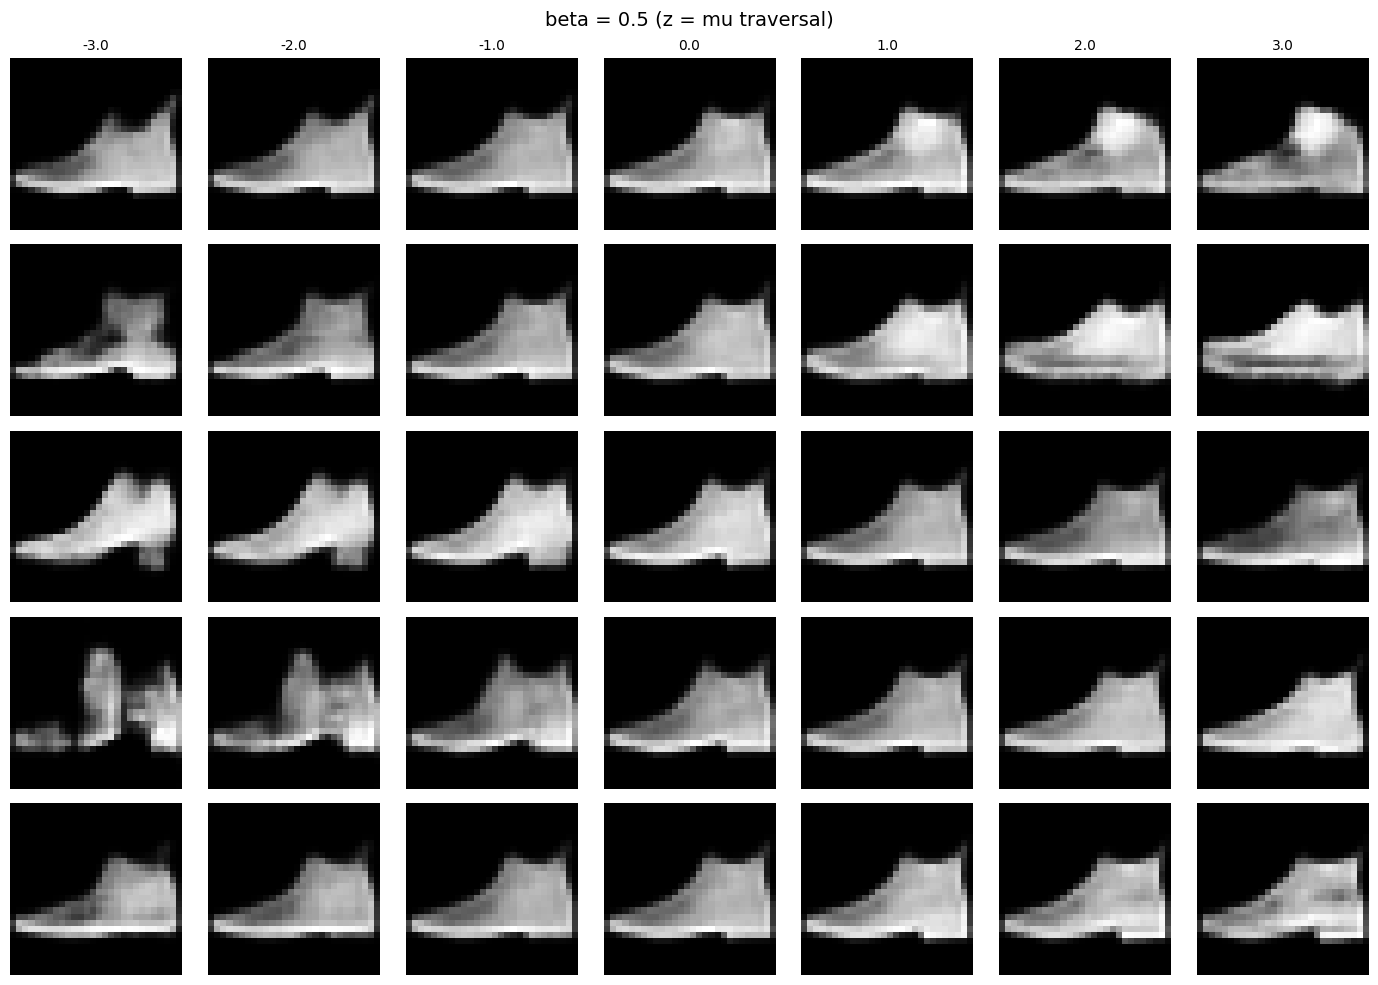


Latent traversal for beta = 1.0


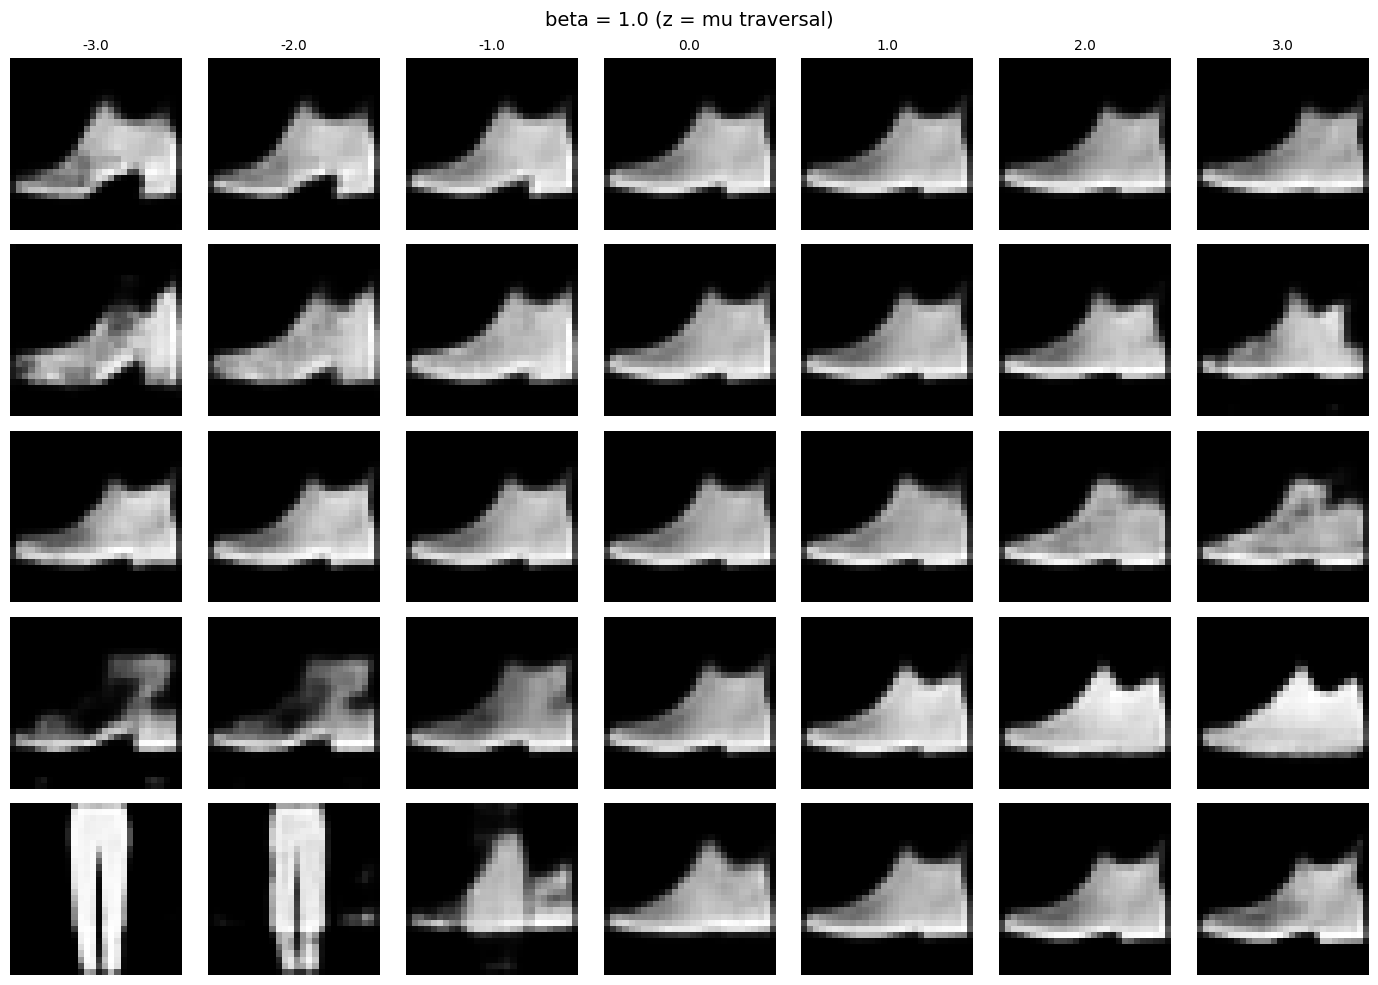


Latent traversal for beta = 4.0


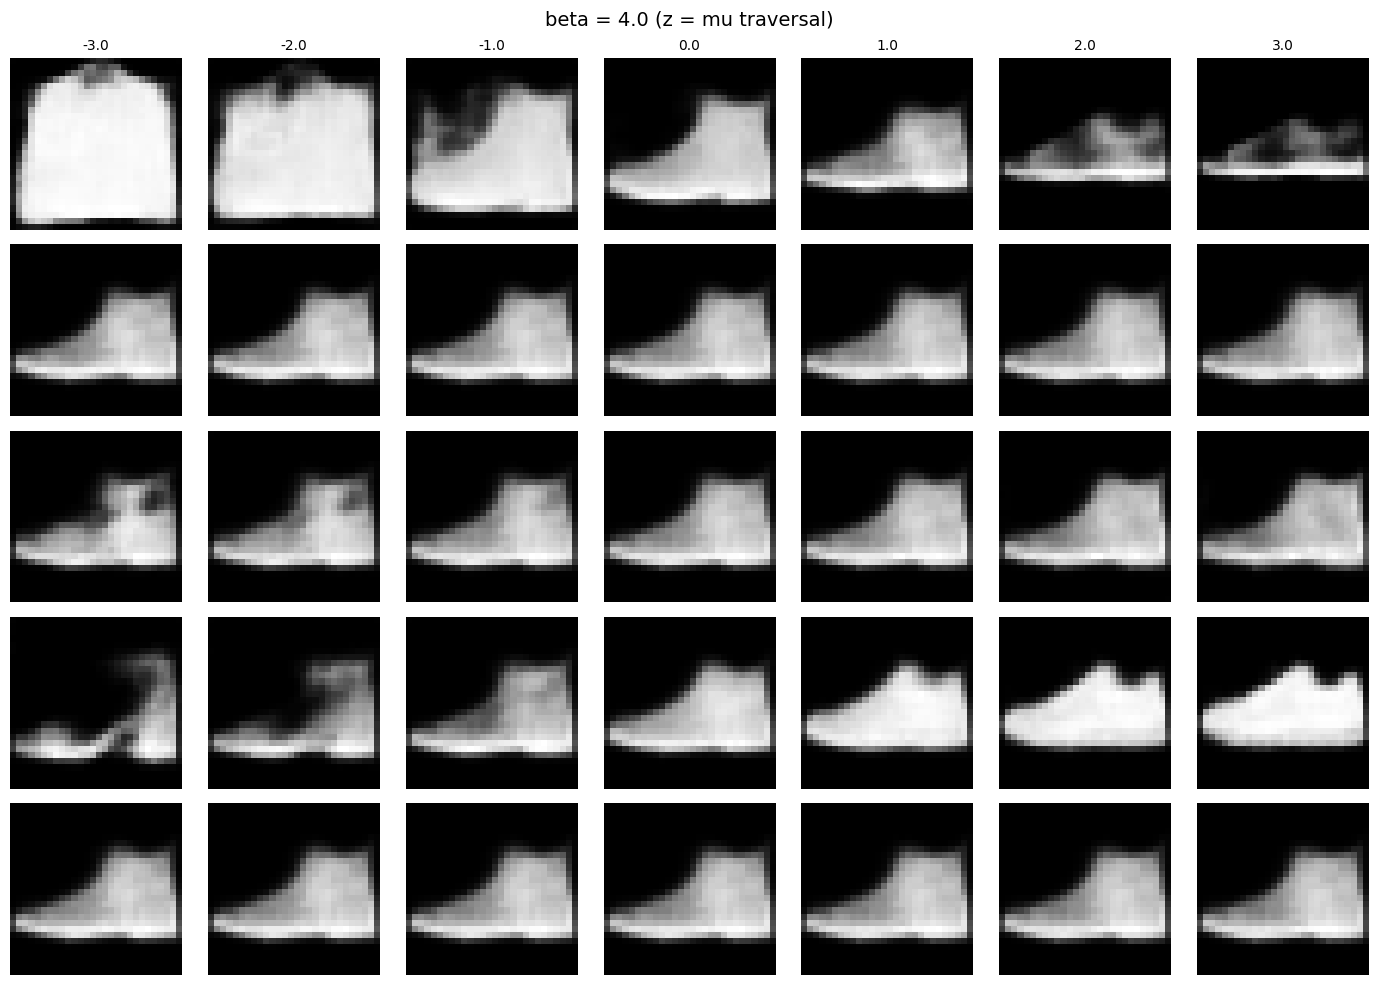

In [39]:
def latent_traversal_grid(model, x, dims, values, device="cuda", title=""):
    """
    model: trained VAE
    x: input image tensor shape (1,1,28,28) normalized to [-1,1]
    dims: list of latent dimensions to traverse
    values: list/np array of values to assign
    """

    model.eval()
    x = x.to(device)

    with torch.no_grad():
        mu, logvar = model.encode(x)
        z0 = mu  # deterministic traversal (recommended)

    rows = len(dims)
    cols = len(values)

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, d in enumerate(dims):
        for c, val in enumerate(values):
            z = z0.clone()
            z[0, d] = float(val)

            with torch.no_grad():
                x_gen = model.decode(z)

            # unnormalize [-1,1] -> [0,1]
            img = (x_gen[0,0].cpu() * 0.5) + 0.5

            axes[r, c].imshow(img, cmap="gray")
            axes[r, c].axis("off")
            if r == 0:
                axes[r, c].set_title(f"{val:.1f}", fontsize=10)
        axes[r, 0].set_ylabel(f"dim {d}", rotation=0, labelpad=25, fontsize=10, va="center")

    if title:
        plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# pick one test image for traversal
x_batch, y_batch = next(iter(test_loader))
x0 = x_batch[:1]  # shape (1,1,28,28)

# Choose 5 dims (simple choice: first 5)
dims_to_traverse = list(range(min(TRAVERSAL_DIMS, LATENT_DIM_PHASE3)))

for b in BETAS:
    print("\n" + "="*80)
    print(f"Latent traversal for beta = {b}")
    print("="*80)
    latent_traversal_grid(
        model=beta_models[b],
        x=x0,
        dims=dims_to_traverse,
        values=TRAVERSAL_VALUES,
        device=device,
        title=f"beta = {b} (z = mu traversal)"
    )

###(3) plot loss curves for each beta

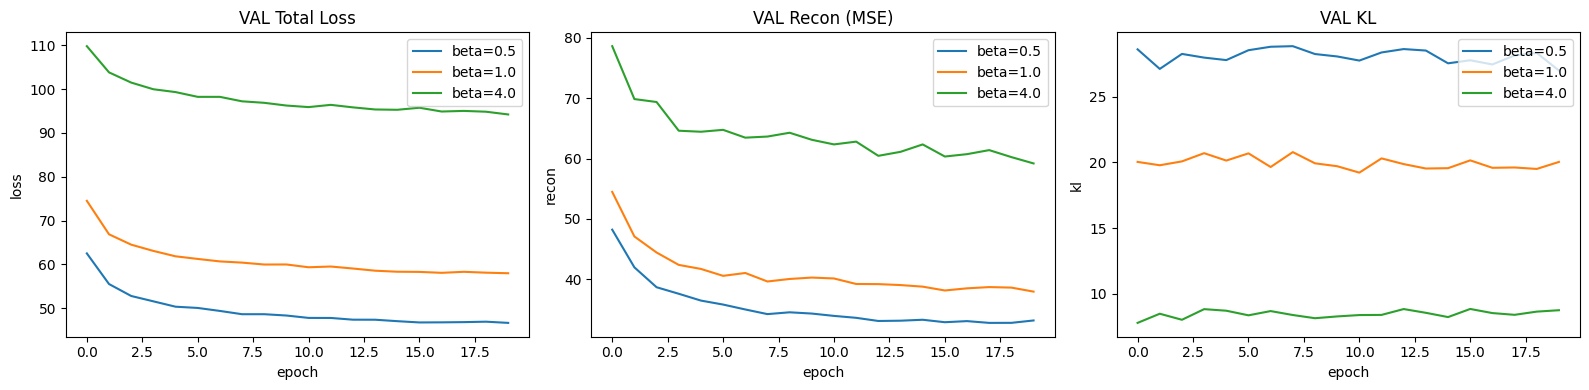

In [40]:
def plot_beta_histories(beta_histories, betas):
    plt.figure(figsize=(16,4))

    # total
    plt.subplot(1,3,1)
    for b in betas:
        plt.plot([h["loss"] for h in beta_histories[b]["val"]], label=f"beta={b}")
    plt.title("VAL Total Loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    # recon
    plt.subplot(1,3,2)
    for b in betas:
        plt.plot([h["recon"] for h in beta_histories[b]["val"]], label=f"beta={b}")
    plt.title("VAL Recon (MSE)"); plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    # KL
    plt.subplot(1,3,3)
    for b in betas:
        plt.plot([h["kl"] for h in beta_histories[b]["val"]], label=f"beta={b}")
    plt.title("VAL KL"); plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    plt.show()

plot_beta_histories(beta_histories, BETAS)

## Phase 4 — Conditional VAE (cVAE): Label-controlled generation

In [41]:
import torch
ckpt = torch.load("./fashion_resnet18_classifier.pt", map_location="cpu")
print(type(ckpt))
if isinstance(ckpt, dict):
    print(ckpt.keys())

<class 'dict'>
dict_keys(['model_state_dict', 'mean', 'std', 'feature_dim', 'seed', 'arch'])


In [42]:
ckpt = torch.load("./fashion_resnet18_classifier.pt", map_location="cpu")
state = ckpt["model_state_dict"]

# find conv1 weight key (usually something like 'conv1.weight' or 'backbone.conv1.weight')
for k, v in state.items():
    if "conv1.weight" in k:
        print("conv1 key:", k, "shape:", tuple(v.shape))
        break

conv1 key: backbone.conv1.weight shape: (64, 1, 3, 3)


In [43]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models

NUM_CLASSES = 10
LATENT_DIM_CVAE = 16
LR_CVAE = 1e-3
EPOCHS_CVAE = 20
BETA_CVAE = 1.0

CLASSIFIER_PATH = "./fashion_resnet18_classifier.pt"


(A) Conditional VAE Model

We inject the one-hot label into:

    Encoder by concatenating a (10-channel) label map to the input image
    Decoder by concatenating the one-hot vector to z


In [44]:
class ConditionalConvVAE(nn.Module):
    def __init__(self, latent_dim=16, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encoder input will be: image (1 channel) + label map (num_classes channels)
        in_ch = 1 + num_classes

        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),      # 14 -> 7
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),     # 7 -> 7
            nn.ReLU(True),
        )
        self.enc_flat_dim = 128 * 7 * 7
        self.fc_mu = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, latent_dim)

        # Decoder takes z concatenated with one-hot label
        self.fc_dec = nn.Linear(latent_dim + num_classes, self.enc_flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # because our dataset is normalized to [-1,1]
        )

    def one_hot(self, y):
        # y: (B,)
        return F.one_hot(y, num_classes=self.num_classes).float()

    def encode(self, x, y):
        # x: (B,1,28,28), y: (B,)
        y_oh = self.one_hot(y).to(x.device)                     # (B,10)
        y_map = y_oh[:, :, None, None].expand(-1, -1, 28, 28)   # (B,10,28,28)
        x_in = torch.cat([x, y_map], dim=1)                     # (B,11,28,28)

        h = self.encoder(x_in).view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        # z: (B,latent_dim), y: (B,)
        y_oh = self.one_hot(y).to(z.device)   # (B,10)
        z_in = torch.cat([z, y_oh], dim=1)    # (B,latent_dim+10)

        h = self.fc_dec(z_in).view(z.size(0), 128, 7, 7)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, y)
        return x_hat, mu, logvar

(B) Loss (same as before)

In [45]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)
    total = recon + beta * kl
    return total, recon, kl

(C) Train/Eval loops for cVAE (uses labels)

In [46]:
def run_epoch_cvae(model, loader, optimizer=None, beta=1.0, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad()

        x_hat, mu, logvar = model(x, y)
        loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n_batches += 1

    return {"loss": total_loss / n_batches,
            "recon": total_recon / n_batches,
            "kl": total_kl / n_batches}

(D) Train cVAE

In [47]:
cvae = ConditionalConvVAE(latent_dim=LATENT_DIM_CVAE, num_classes=NUM_CLASSES).to(device)
opt = torch.optim.Adam(cvae.parameters(), lr=LR_CVAE)

cvae_history = {"train": [], "val": []}

for epoch in range(1, EPOCHS_CVAE + 1):
    tr = run_epoch_cvae(cvae, train_loader, optimizer=opt, beta=BETA_CVAE, device=device)
    va = run_epoch_cvae(cvae, val_loader, optimizer=None, beta=BETA_CVAE, device=device)
    cvae_history["train"].append(tr)
    cvae_history["val"].append(va)

    print(f"Epoch {epoch:02d} | "
          f"train loss={tr['loss']:.4f} recon={tr['recon']:.4f} kl={tr['kl']:.4f} | "
          f"val loss={va['loss']:.4f} recon={va['recon']:.4f} kl={va['kl']:.4f}")

# Test report (optional but useful)
test_c = run_epoch_cvae(cvae, test_loader, optimizer=None, beta=BETA_CVAE, device=device)
print("\nCVAE TEST METRICS:")
print(f"reconstruction (MSE): {test_c['recon']:.6f}")
print(f"regularization (KL):  {test_c['kl']:.6f}")
print(f"total:               {test_c['loss']:.6f}")

Epoch 01 | train loss=119.2248 recon=105.3273 kl=13.8976 | val loss=74.6985 recon=58.9963 kl=15.7021
Epoch 02 | train loss=68.4163 recon=52.4519 kl=15.9644 | val loss=65.7763 recon=49.6753 kl=16.1010
Epoch 03 | train loss=63.6507 recon=47.2261 kl=16.4247 | val loss=62.9546 recon=46.0252 kl=16.9294
Epoch 04 | train loss=61.2418 recon=44.7618 kl=16.4800 | val loss=61.0297 recon=44.9524 kl=16.0774
Epoch 05 | train loss=59.6152 recon=43.1383 kl=16.4769 | val loss=59.5196 recon=42.7988 kl=16.7208
Epoch 06 | train loss=58.4772 recon=42.0159 kl=16.4613 | val loss=58.9192 recon=42.4726 kl=16.4466
Epoch 07 | train loss=57.6231 recon=41.1600 kl=16.4630 | val loss=58.2162 recon=41.8958 kl=16.3205
Epoch 08 | train loss=56.9283 recon=40.4723 kl=16.4560 | val loss=58.2992 recon=41.4352 kl=16.8640
Epoch 09 | train loss=56.3162 recon=39.9039 kl=16.4123 | val loss=57.0963 recon=40.3749 kl=16.7214
Epoch 10 | train loss=55.7703 recon=39.3579 kl=16.4124 | val loss=56.5921 recon=39.7647 kl=16.8274
Epoch 11

(E) Label-controlled generation: 20 images per class (grid)

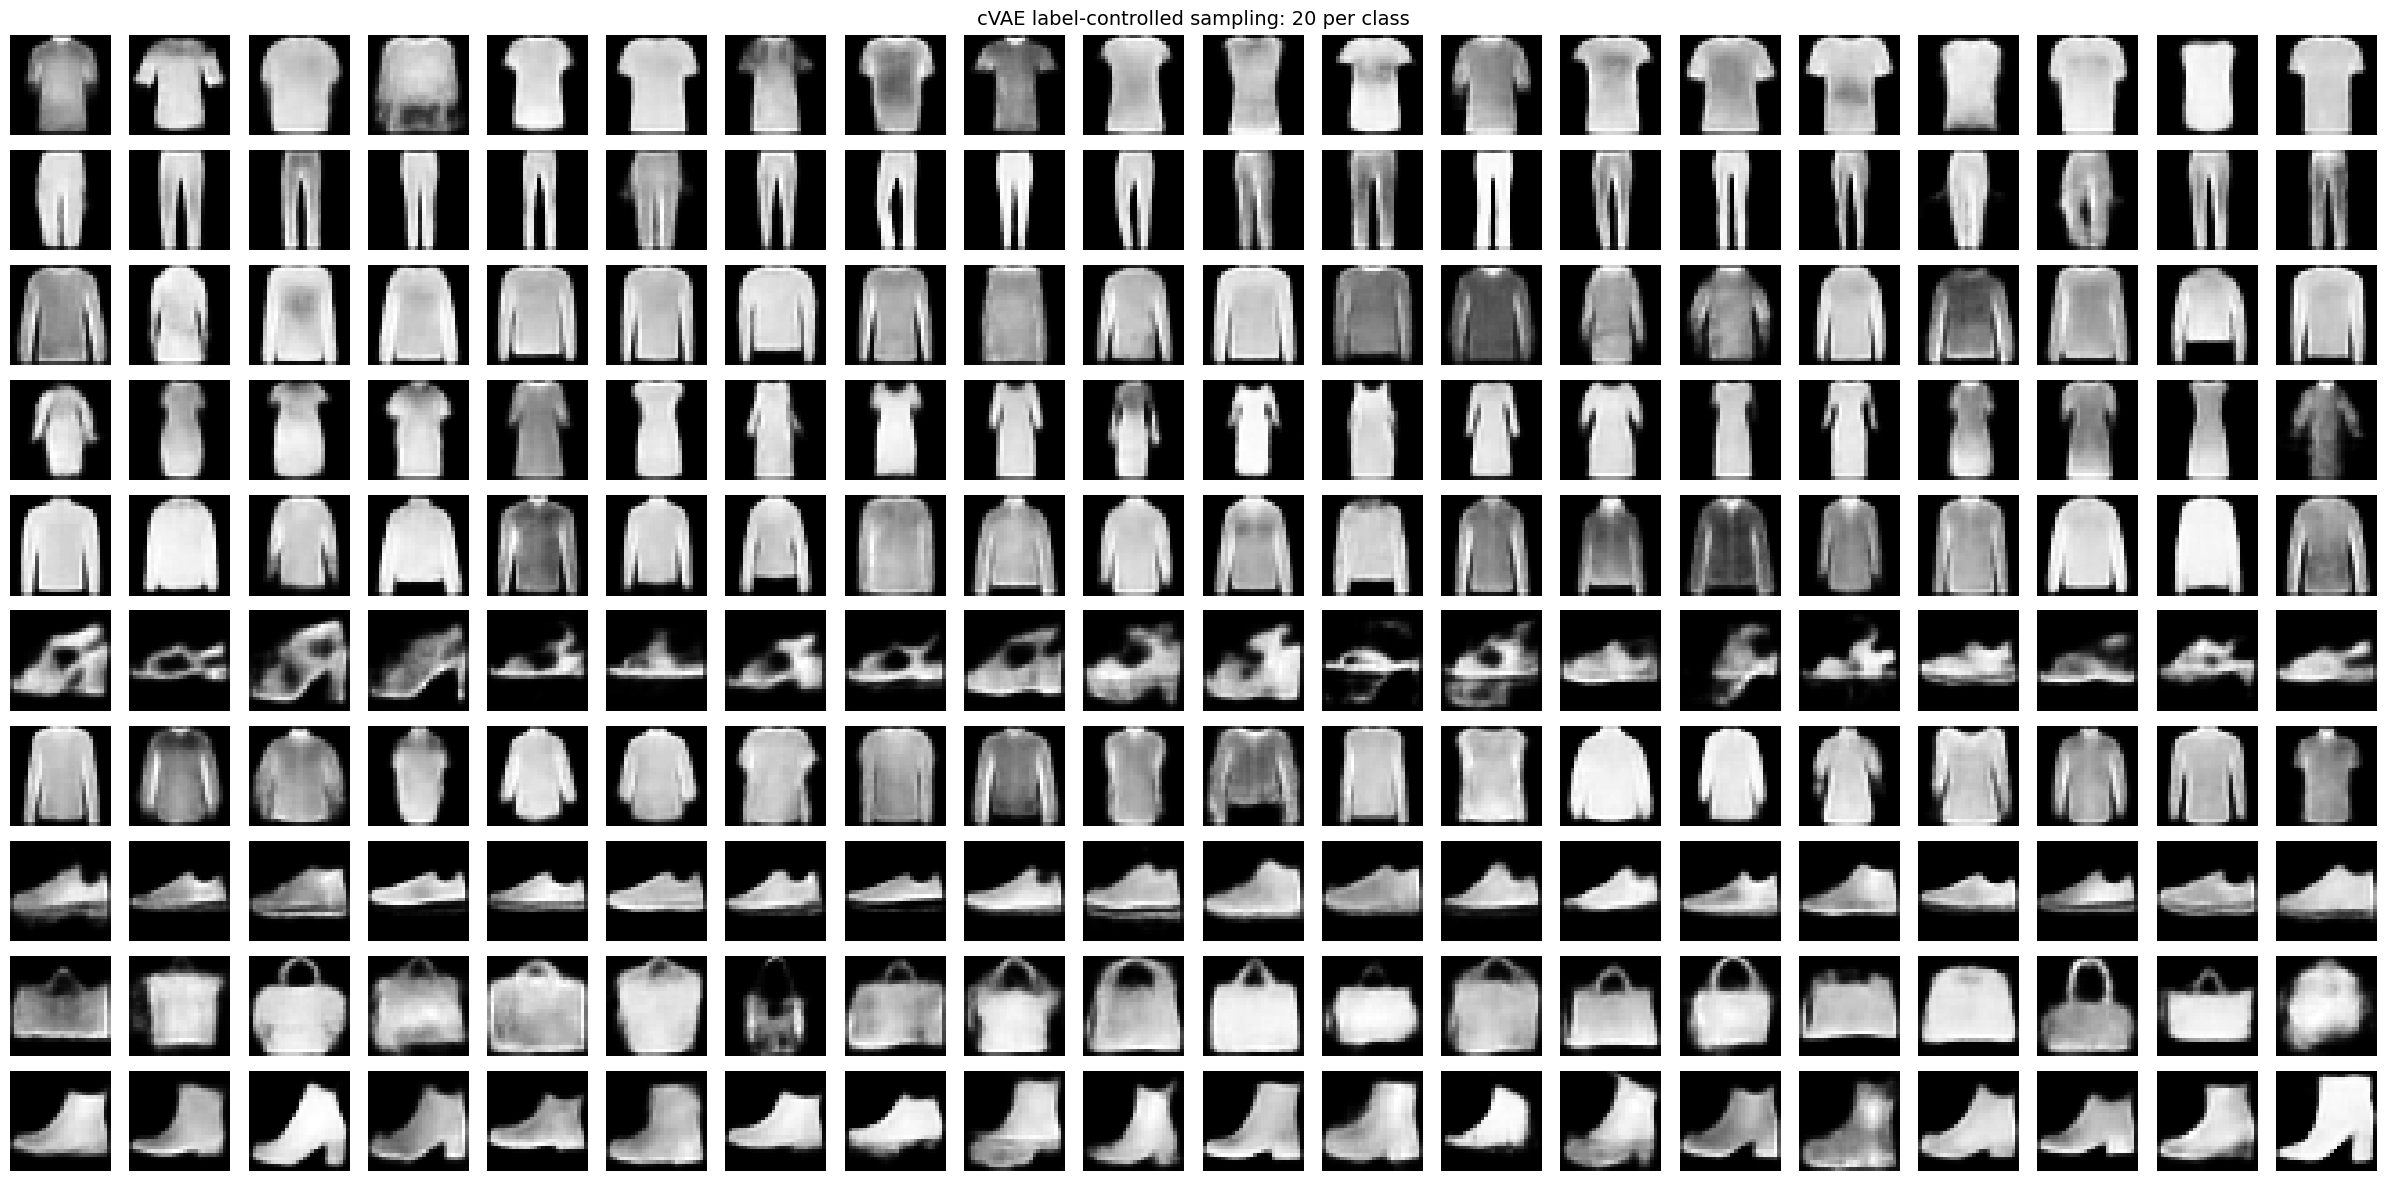

In [48]:
def generate_per_class_grid_cvae(model, n_per_class=20, num_classes=10, device="cuda"):
    model.eval()

    all_imgs = []
    all_labels = []
    with torch.no_grad():
        for cls in range(num_classes):
            y = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
            z = torch.randn(n_per_class, model.latent_dim, device=device)
            x_gen = model.decode(z, y)  # (n,1,28,28)
            all_imgs.append(x_gen.cpu())
            all_labels.append(y.cpu())

    x_gen = torch.cat(all_imgs, dim=0)  # (num_classes*n,1,28,28)
    y_gen = torch.cat(all_labels, dim=0)

    # display: rows = classes, cols = n_per_class
    x_vis = (x_gen * 0.5) + 0.5  # [-1,1] -> [0,1]
    rows, cols = num_classes, n_per_class
    fig, axes = plt.subplots(rows, cols, figsize=(1.2*cols, 1.2*rows))

    idx = 0
    for r in range(rows):
        for c in range(cols):
            axes[r, c].imshow(x_vis[idx, 0], cmap="gray")
            axes[r, c].axis("off")
            idx += 1
        axes[r, 0].set_ylabel(f"class {r}", rotation=0, labelpad=30, va="center")

    plt.suptitle(f"cVAE label-controlled sampling: {n_per_class} per class", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_per_class_grid_cvae(cvae, n_per_class=20, num_classes=NUM_CLASSES, device=device)

(F) Load provided classifier (.pt) and evaluate controllability accuracy

1) Build classifier architecture (ResNet18, 1-channel input)

In [49]:
def build_resnet18_1ch(num_classes=10):
    m = models.resnet18(weights=None)
    # replace first conv to accept 1 channel and use 3x3 kernel (as in checkpoint)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    # remove maxpool for small images (common for CIFAR/FashionMNIST adaptations)
    m.maxpool = nn.Identity()
    # final layer
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

2) Load checkpoint + normalization parameters

In [57]:
def build_resnet18_1ch(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def strip_prefix(state_dict, prefix):
    out = {}
    for k, v in state_dict.items():
        if k.startswith(prefix):
            out[k[len(prefix):]] = v
        else:
            out[k] = v
    return out

ckpt = torch.load(CLASSIFIER_PATH, map_location="cpu")
state = ckpt["model_state_dict"]

# 1) remove "backbone." prefix
state = strip_prefix(state, "backbone.")

# 2) map "head.*" -> "fc.*" if present
if "head.weight" in state and "head.bias" in state:
    state["fc.weight"] = state.pop("head.weight")
    state["fc.bias"] = state.pop("head.bias")

classifier = build_resnet18_1ch(num_classes=NUM_CLASSES).to(device)
missing, unexpected = classifier.load_state_dict(state, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

classifier.eval()

clf_mean = ckpt["mean"]
clf_std = ckpt["std"]
print("Classifier mean/std:", clf_mean, clf_std)

Missing keys: []
Unexpected keys: []
Classifier mean/std: (0.286,) (0.353,)


3) Preprocess generated images for classifier
Classifier usually expects inputs normalized as:
$$x' = (x - mean) / std$$
We will convert our generated images from [-1,1] -> [0,1] first, then normalize using ckpt mean/std.

In [58]:
def preprocess_for_classifier(x, mean, std, device="cuda"):
    """
    x: tensor in [-1,1] with shape (B,1,28,28)
    returns: normalized tensor for classifier
    """
    x01 = (x + 1.0) / 2.0  # [-1,1] -> [0,1]
    mean_t = torch.tensor(mean, device=device).view(1,1,1,1)
    std_t = torch.tensor(std, device=device).view(1,1,1,1)
    return (x01 - mean_t) / std_t

4) Compute overall + per-class accuracy on generated images

In [59]:
@torch.no_grad()
def classifier_accuracy_on_generated(classifier, x_gen, y_true, mean, std, device="cuda"):
    """
    x_gen: generated images in [-1,1], shape (N,1,28,28)
    y_true: intended labels, shape (N,)
    """
    classifier.eval()
    x_in = preprocess_for_classifier(x_gen.to(device), mean, std, device=device)
    logits = classifier(x_in)
    y_pred = logits.argmax(dim=1).cpu()

    y_true_cpu = y_true.cpu()
    overall_acc = (y_pred == y_true_cpu).float().mean().item()

    per_class = {}
    for cls in range(NUM_CLASSES):
        mask = (y_true_cpu == cls)
        if mask.sum().item() == 0:
            per_class[cls] = float("nan")
        else:
            per_class[cls] = (y_pred[mask] == y_true_cpu[mask]).float().mean().item()

    return overall_acc, per_class

In [60]:
@torch.no_grad()
def sample_cvae_dataset(model, n_per_class=20, num_classes=10, device="cuda"):
    model.eval()
    xs, ys = [], []
    for cls in range(num_classes):
        y = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        z = torch.randn(n_per_class, model.latent_dim, device=device)
        x = model.decode(z, y)  # [-1,1]
        xs.append(x.cpu())
        ys.append(y.cpu())
    return torch.cat(xs, dim=0), torch.cat(ys, dim=0)

x_cvae_eval, y_cvae_eval = sample_cvae_dataset(cvae, n_per_class=20, num_classes=NUM_CLASSES, device=device)

overall_acc, per_class_acc = classifier_accuracy_on_generated(
    classifier, x_cvae_eval, y_cvae_eval, mean=clf_mean, std=clf_std, device=device
)

print("\nClassifier controllability report on cVAE generated images:")
print("Overall accuracy:", overall_acc)
print("Per-class accuracy:")
for cls in range(NUM_CLASSES):
    print(f"class {cls}: {per_class_acc[cls]:.4f}")


Classifier controllability report on cVAE generated images:
Overall accuracy: 0.8899999856948853
Per-class accuracy:
class 0: 0.8500
class 1: 1.0000
class 2: 0.9500
class 3: 0.9000
class 4: 0.5500
class 5: 0.9500
class 6: 0.8000
class 7: 0.9500
class 8: 1.0000
class 9: 0.9500


(G) Short comparison with unconditional VAE (no label)

In [61]:
@torch.no_grad()
def sample_unconditional_vae(model_uncond, n_total=200, device="cuda"):
    model_uncond.eval()
    z = torch.randn(n_total, model_uncond.latent_dim, device=device)
    x = model_uncond.decode(z)  # [-1,1]
    return x.cpu()

# create a "target label set" (same structure as cVAE eval: 20 per class)
y_targets = torch.cat([torch.full((20,), cls, dtype=torch.long) for cls in range(NUM_CLASSES)], dim=0)

x_uncond_eval = sample_unconditional_vae(baseline_model if 'baseline_model' in globals() else model, n_total=len(y_targets), device=device)

overall_acc_uncond, per_class_acc_uncond = classifier_accuracy_on_generated(
    classifier, x_uncond_eval, y_targets, mean=clf_mean, std=clf_std, device=device
)

print("\nComparison (Unconditional VAE samples, evaluated against requested labels):")
print("Overall accuracy:", overall_acc_uncond)
print("Per-class accuracy:")
for cls in range(NUM_CLASSES):
    print(f"class {cls}: {per_class_acc_uncond[cls]:.4f}")


Comparison (Unconditional VAE samples, evaluated against requested labels):
Overall accuracy: 0.07500000298023224
Per-class accuracy:
class 0: 0.0500
class 1: 0.1500
class 2: 0.2500
class 3: 0.0500
class 4: 0.0500
class 5: 0.0000
class 6: 0.0000
class 7: 0.0500
class 8: 0.0500
class 9: 0.1000


show a few unconditional samples:

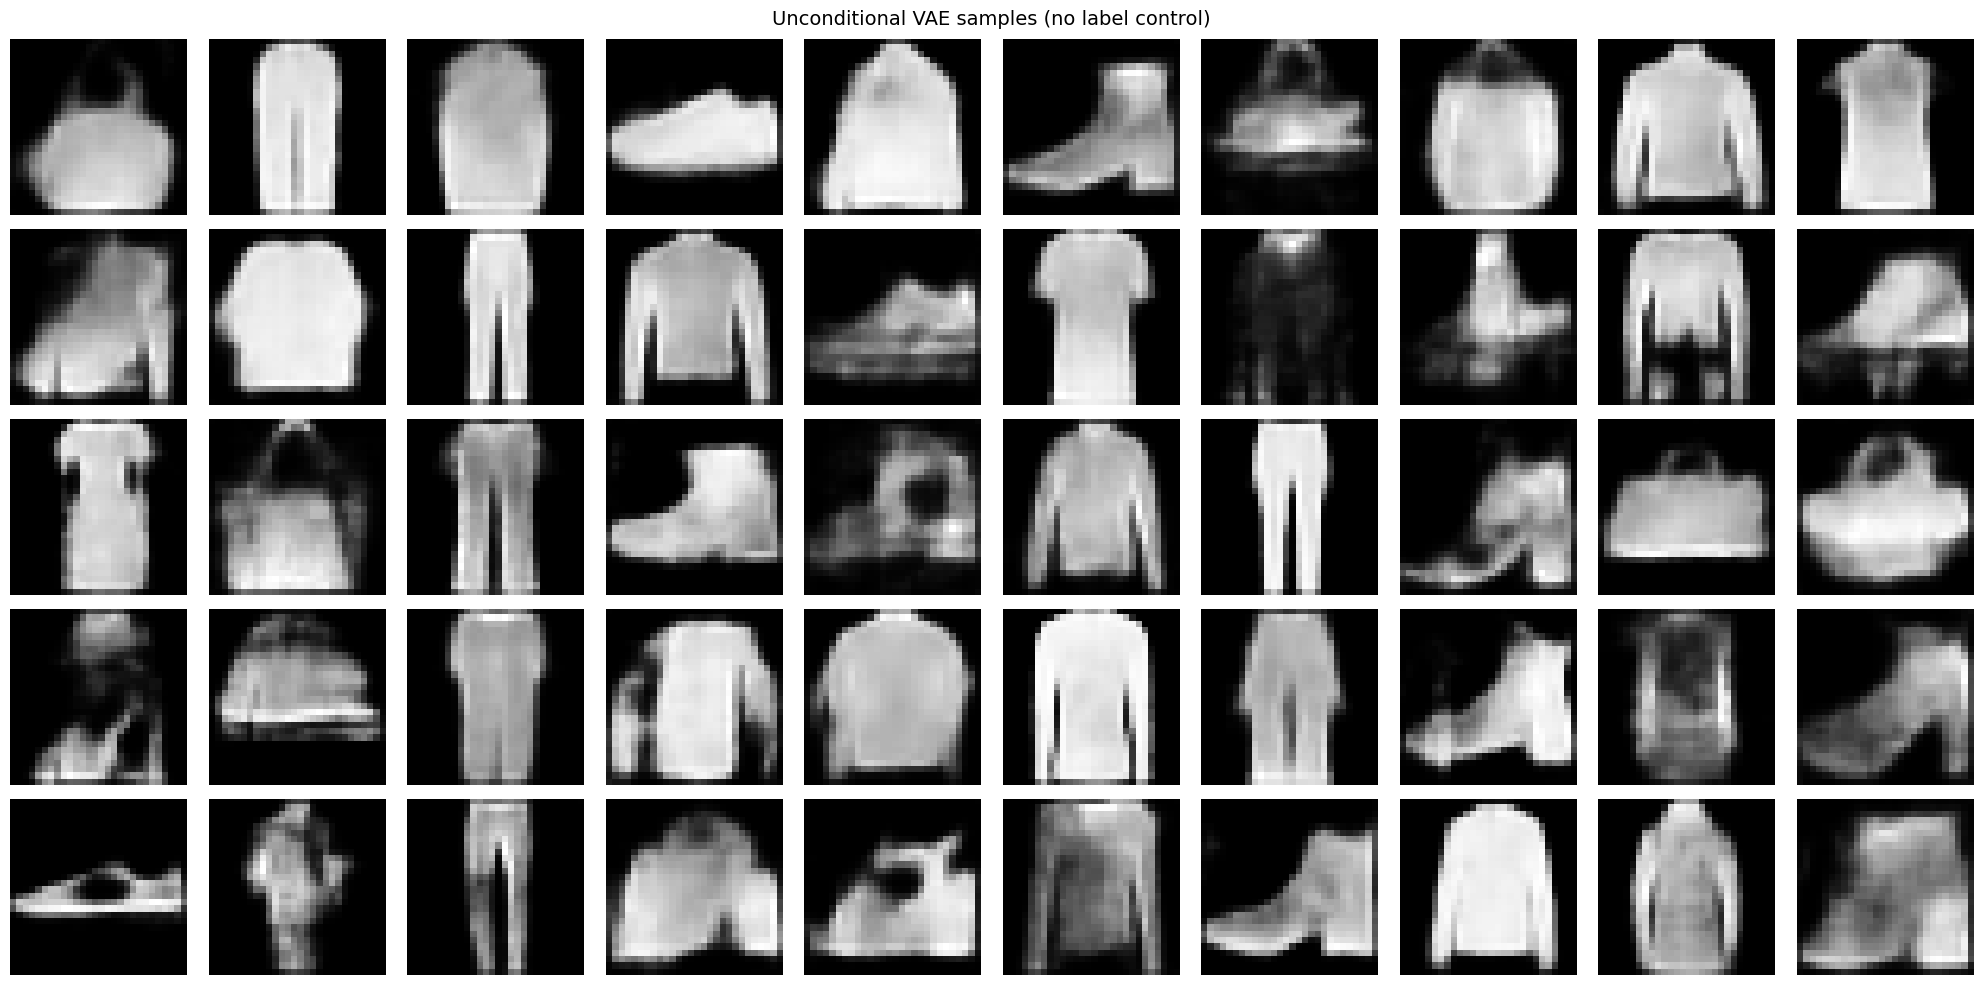

In [62]:
def show_samples_tensor(x, n=50, title=""):
    # x in [-1,1]
    x_vis = (x[:n] * 0.5) + 0.5
    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(x_vis[i,0], cmap="gray")
        ax.axis("off")
    if title:
        plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples_tensor(x_uncond_eval, n=50, title="Unconditional VAE samples (no label control)")